In [1]:
import yaml
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import re
import numpy as np
import matplotlib.pyplot as plt
from typing import Any, Dict, List, Optional, Tuple, Union
import pandas as pd

#from typing import Any, Dict, List, Union


from tqdm import tqdm
import json

from thesis_project.models.keyword_spotting import KWSBase, KWSDynamic
from thesis_project.models.components.routers import GRURouter
from thesis_project.utils.paths import get_data_dir
from thesis_project.datasets import SpeechCommandsGoogle
#from thesis_project.training.key_word_spotting.train_base_loop import fit_base_model, validate_model
from base_config_temp import cfg, noise_train_cfg, noise_eval_cfg

MODEL_DIR = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/"
MODEL_CHECKPOINT = MODEL_DIR + "best_model.pth"
MODEL_HISTORY = np.load(MODEL_DIR + "history.npy", allow_pickle=True).item()

In [2]:
# Load per-sample results from CSV files
all_per_sample_dfs = {}
comb_names = ["comb_1"]  # Add other combination names if needed
for comb_name in comb_names:
    df = pd.read_csv(MODEL_DIR + f"per_sample_results_{comb_name}_golden.csv")
    all_per_sample_dfs[comb_name] = df

print(f"\nLoaded per-sample results from {MODEL_DIR}:")


Loaded per-sample results from /Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/:


### Analysis of results for combination 1

In [3]:
df_for_viz = all_per_sample_dfs["comb_1"]
# get the length of a single validation set (samples per snr_eval, rank combo)
# Since samples are in the same order for all noise files, we can compute length from any group
len_single_val_set = df_for_viz.groupby(['val_set_id', 'snr_eval', 'rank']).size().iloc[0]
print(f"Length of single validation set: {len_single_val_set}")

# Assigning an ID to each sample based on its position within each (snr_eval, rank) group
# This ID is consistent across all val_set_id (noise files) since samples are loaded in same order
df_for_viz['id'] = df_for_viz.groupby(['snr_eval', 'rank']).cumcount() % len_single_val_set

# Verify: each (id, snr_eval, rank) should have exactly NUMBER_OF_VAL_SETS rows (one per noise file)
print(f"Unique noise files: {df_for_viz['noise_file'].unique().tolist()}")
print(f"Rows per (id, snr_eval, rank): {df_for_viz.groupby(['id', 'snr_eval', 'rank']).size().iloc[0]} (expected: {len(df_for_viz['val_set_id'].unique())})")

Length of single validation set: 4515
Unique noise files: ['doing_the_dishes.wav', 'dude_miaowing.wav', 'exercise_bike.wav', 'pink_noise.wav', 'running_tap.wav', 'white_noise.wav']
Rows per (id, snr_eval, rank): 6 (expected: 6)


In [19]:
def calculate_accuracy_by_rank(df, rank, snr_col='snr_eval', correct_col='correct', rank_col='rank'):
    """
    Calculates accuracy for each SNR, and micro/macro averages for a given rank.
    Args:
        df (pd.DataFrame): DataFrame containing columns for SNR, correct predictions, and rank.
        rank (int): The rank to filter on.
        snr_col (str): Column name for SNR values.
        correct_col (str): Column name for correct predictions (boolean).
        rank_col (str): Column name for rank.
    Returns:
        dict: Dictionary with per-SNR accuracy, micro avg, and macro avg.
    """
    filtered = df[df[rank_col] == rank]
    acc_per_snr = {}
    for snr, group in filtered.groupby(snr_col):
        acc = group[correct_col].mean()
        acc_per_snr[snr] = acc
    # Micro avg: accuracy over all samples
    micro_avg = filtered[correct_col].mean() if not filtered.empty else float('nan')
    # Macro avg: mean of per-SNR accuracies
    macro_avg = sum(acc_per_snr.values()) / len(acc_per_snr) if acc_per_snr else float('nan')
    return {
        'accuracy_per_snr': acc_per_snr,
        'micro_avg': micro_avg,
        'macro_avg': macro_avg
    }

In [20]:
calculate_accuracy_by_rank(df_for_viz, rank=18)

{'accuracy_per_snr': {-5.0: np.float64(0.7321520856404578),
  0.0: np.float64(0.823624953857512),
  5.0: np.float64(0.8697674418604651),
  10.0: np.float64(0.8935400516795866),
  15.0: np.float64(0.9037283130306386),
  inf: np.float64(0.9141011443337025)},
 'micro_avg': np.float64(0.8561523317337271),
 'macro_avg': np.float64(0.8561523317337271)}

In [22]:
calculate_accuracy_by_rank(df_for_viz, rank=20)

{'accuracy_per_snr': {-5.0: np.float64(0.7377999261720192),
  0.0: np.float64(0.827390180878553),
  5.0: np.float64(0.8701365817644887),
  10.0: np.float64(0.8917312661498707),
  15.0: np.float64(0.9029162052417866),
  inf: np.float64(0.9135474344776671)},
 'micro_avg': np.float64(0.8572535991140642),
 'macro_avg': np.float64(0.8572535991140642)}

In [16]:
print(df.columns.tolist())
print(df.head())

['snr_eval', 'rank', 'pred', 'target', 'correct', 'val_set_id', 'noise_file', 'label', 'utterance', 'noise_type', 'snr_sample', 'id']
   snr_eval  rank  pred  target  correct  val_set_id            noise_file  \
0      -5.0     1    10       0    False           0  doing_the_dishes.wav   
1      -5.0     1    10       0    False           0  doing_the_dishes.wav   
2      -5.0     1    10       0    False           0  doing_the_dishes.wav   
3      -5.0     1    10       0    False           0  doing_the_dishes.wav   
4      -5.0     1    10       0    False           0  doing_the_dishes.wav   

  label utterance        noise_type  snr_sample  id  
0  down      down  doing_the_dishes        -5.0   0  
1  down      down  doing_the_dishes        -5.0   1  
2  down      down  doing_the_dishes        -5.0   2  
3  down      down  doing_the_dishes        -5.0   3  
4  down      down  doing_the_dishes        -5.0   4  


In [4]:
import math
import pandas as pd
import matplotlib.pyplot as plt


def plot_min_correct_rank_distributions_grid(
    df: pd.DataFrame,
    *,
    snr_col: str = "snr_eval",
    rank_col: str = "rank",
    correct_col: str = "correct",
    id_col: str = "id",
    normalize: bool = True,
    figsize_per_plot=(5, 4),
    ncols: int = 3,
):
    """
    Grid of plots (one per SNR):
      - histogram of min rank where each sample becomes correct
      - shared x/y limits across all SNR plots
      - overlays mean / median / mode / 95th percentile
      - each subplot has its OWN legend with numeric values
      - x ticks shown on ALL plots and are every other integer
    """

    needed = {snr_col, rank_col, correct_col, id_col}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    # --- keep only rows where prediction is correct ---
    correct_df = df[df[correct_col].astype(bool)]

    # --- min rank where sample becomes correct ---
    min_rank_df = (
        correct_df
        .groupby([snr_col, id_col])[rank_col]
        .min()
        .reset_index(name="min_rank")
    )

    # --- all samples (to detect never-correct) ---
    all_samples = df[[snr_col, id_col]].drop_duplicates()

    per_sample = all_samples.merge(
        min_rank_df,
        on=[snr_col, id_col],
        how="left",
    )

    # -------------------------------------------------
    # PRECOMPUTE GLOBAL AXIS LIMITS
    # -------------------------------------------------
    all_ranks = per_sample["min_rank"].dropna().astype(int)
    if len(all_ranks) == 0:
        return per_sample

    xmin, xmax = int(all_ranks.min()), int(all_ranks.max())

    ymax = 0.0
    for _, sub in per_sample.groupby(snr_col, sort=False):
        ranks = sub["min_rank"].dropna().astype(int)
        if len(ranks) == 0:
            continue
        counts = ranks.value_counts().sort_index()
        y = counts.to_numpy()
        if normalize:
            y = y / y.sum()
        ymax = max(ymax, float(y.max()))

    # -------------------------------------------------
    # GRID SETUP
    # -------------------------------------------------
    snrs = list(per_sample[snr_col].drop_duplicates())
    n_plots = len(snrs)
    nrows = math.ceil(n_plots / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows),
        sharex=True,
        sharey=True,
    )
    axes = axes.flatten() if n_plots > 1 else [axes]

    xticks = list(range(xmin, xmax + 1, 2))

    # -------------------------------------------------
    # PLOT PER SNR
    # -------------------------------------------------
    for ax, snr in zip(axes, snrs):
        sub = per_sample[per_sample[snr_col] == snr]
        ranks = sub["min_rank"].dropna().astype(int)

        total = len(sub)
        never = int(sub["min_rank"].isna().sum())
        never_pct = 100.0 * never / total if total else 0.0

        if len(ranks) > 0:
            counts = ranks.value_counts().sort_index()
            x = counts.index.to_numpy()
            y = counts.to_numpy()

            if normalize:
                y = y / y.sum()

            ax.bar(x, y)

            # ---- statistics ----
            mean_rank = float(ranks.mean())
            median_rank = float(ranks.median())
            mode_rank = int(ranks.mode().iloc[0])
            p95_rank = float(ranks.quantile(0.95))

            ax.axvline(mean_rank, linestyle="--", linewidth=2,
                       label=f"Mean = {mean_rank:.2f}",color="C1")
            ax.axvline(median_rank, linestyle="-", linewidth=2,
                       label=f"Median = {median_rank:.2f}", color="C2")
            ax.axvline(mode_rank, linestyle=":", linewidth=2,
                       label=f"Mode = {mode_rank}",color="C3")
            ax.axvline(p95_rank, linestyle="-.", linewidth=2,
                       label=f"P95 = {p95_rank:.2f}",color="C4")

            ax.legend(frameon=False, fontsize=9)

        else:
            ax.text(0.5, 0.5, "No correct samples",
                    ha="center", va="center", transform=ax.transAxes)

        ax.set_title(
            f"SNR={snr}\nnever: {never}/{total} ({never_pct:.1f}%)",
            fontsize=10,
        )

        ax.set_xlim(xmin - 0.5, xmax + 0.5)
        ax.set_ylim(0, ymax * 1.05)
        ax.grid(axis="y", alpha=0.3)

        # ---- force x ticks on all plots ----
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticks, rotation=90)
        ax.tick_params(axis="x", labelbottom=True)

    # hide unused axes
    for ax in axes[n_plots:]:
        ax.axis("off")

    # -------------------------------------------------
    # GLOBAL LABELS
    # -------------------------------------------------
    fig.text(0.5, 0.04, "Minimum rank where sample is correct", ha="center")
    fig.text(
        0.04,
        0.5,
        "Probability" if normalize else "Count",
        va="center",
        rotation="vertical",
    )

    fig.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
    plt.show()

    return per_sample

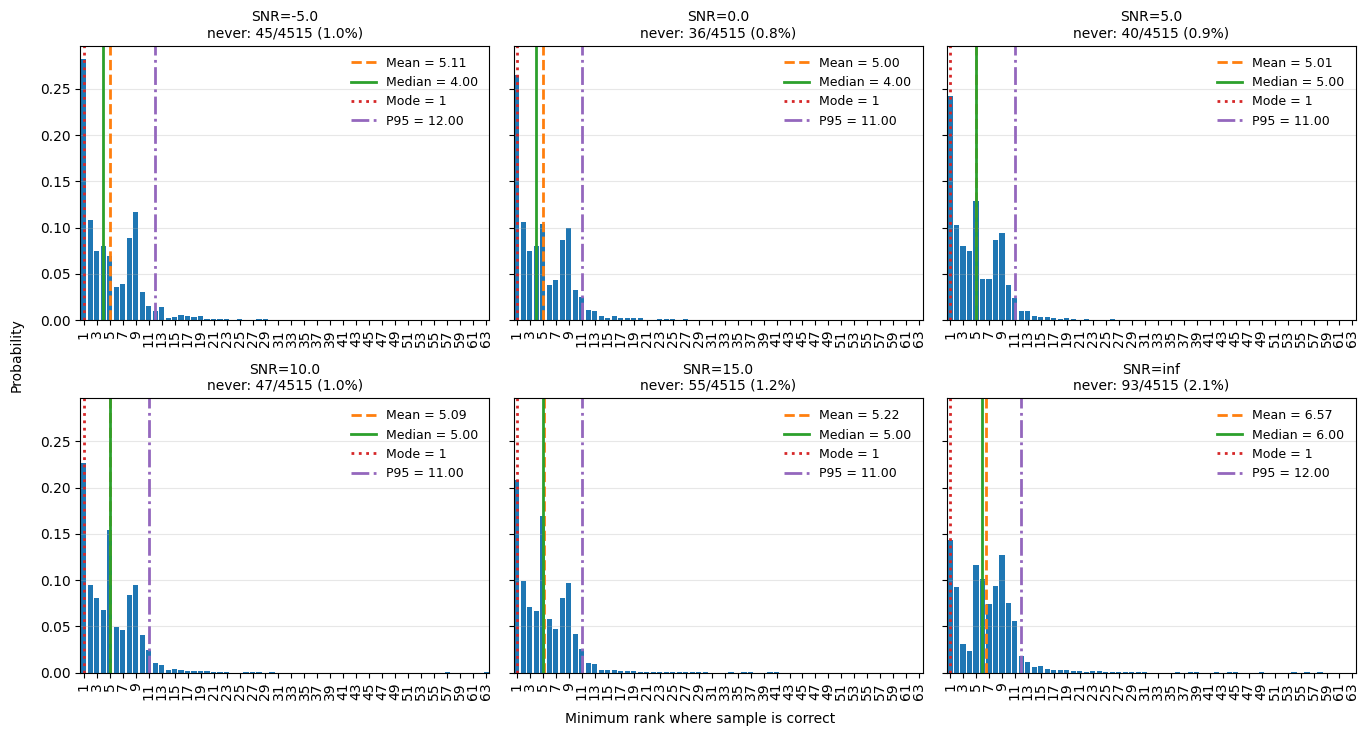

In [5]:
per_sample_min_correct_rank = plot_min_correct_rank_distributions_grid(
    df=df_for_viz,
    normalize=True,
)

In [6]:
def plot_min_correct_rank_by_noise_type(
    df: pd.DataFrame,
    snr_value: float,
    *,
    snr_col: str = "snr_eval",
    rank_col: str = "rank",
    correct_col: str = "correct",
    id_col: str = "id",
    noise_col: str = "noise_file",  # or "val_set_id"
    label_col: str = "label",
    normalize: bool = True,
    figsize_per_plot: Tuple[float, float] = (10, 2.5),
    stack_by_label: bool = True,
    cmap_name: str = "tab20",
    require_stable: bool = False,
    aggregate_noise: bool = False,
):
    """
    For a given SNR value, plot the histogram of minimum rank where each sample
    becomes correct (or becomes stably correct), with one subplot per noise type
    (or a single aggregated plot if aggregate_noise=True).
    
    Plots are stacked vertically with a shared x-axis to easily visualize
    distribution shifts across noise types.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with per-sample results
    snr_value : float
        The SNR value to filter on
    snr_col : str
        Column name for SNR values
    rank_col : str
        Column name for rank values
    correct_col : str
        Column name for correctness (bool or 0/1)
    id_col : str
        Column name for sample ID
    noise_col : str
        Column name for noise type / validation set identifier
    label_col : str
        Column name for the class label
    normalize : bool
        If True, show probability; if False, show counts
    figsize_per_plot : tuple
        (width, height) per subplot
    stack_by_label : bool
        If True, stack bars by label with different colors
    cmap_name : str
        Colormap name for label colors
    require_stable : bool
        If False (default), find min rank where sample is correct.
        If True, find min rank where sample is correct AND stays correct 
        for all higher ranks. This introduces two "never" categories:
        - "never correct": never predicted correctly at any rank
        - "never stable": correct at some rank(s), but never stably correct
    aggregate_noise : bool
        If False (default), show one subplot per noise type.
        If True, show a single plot that sums/aggregates across all noise types.
        The "never correct" and "never stable" counts are summed across noise types.
        
    Returns
    -------
    per_sample : pd.DataFrame
        DataFrame with min_rank per sample and noise type.
        When require_stable=True, also includes 'ever_correct' and 'ever_stable' columns.
    """
    
    needed = {snr_col, rank_col, correct_col, id_col, noise_col}
    if stack_by_label:
        needed.add(label_col)
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")
    
    # Filter to the specified SNR
    df_snr = df[df[snr_col] == snr_value].copy()
    if len(df_snr) == 0:
        raise ValueError(f"No data found for SNR={snr_value}")
    
    # Get unique labels in sorted order (consistent across all plots)
    all_labels = sorted(df_snr[label_col].unique()) if stack_by_label else []
    n_labels = len(all_labels)
    
    # Create color mapping for labels
    cmap = plt.cm.get_cmap(cmap_name, n_labels) if stack_by_label else None
    label_colors = {label: cmap(i) for i, label in enumerate(all_labels)} if stack_by_label else {}
    
    # Get unique noise types
    noise_types = sorted(df_snr[noise_col].unique())
    
    # Get all ranks for this SNR (needed for stable computation)
    all_ranks_in_data = sorted(df_snr[rank_col].unique())
    max_rank_in_data = max(all_ranks_in_data)
    
    # ============================================================
    # STEP 1: For each noise type separately, compute:
    #   - Which samples are ever correct (at any rank)
    #   - For samples that are ever correct, what's the min rank
    #   - If require_stable: find min rank where sample stays correct
    # ============================================================
    
    def find_min_stable_rank(sample_df, rank_col, correct_col, max_rank):
        """
        Find the minimum rank where the sample is correct AND stays correct
        for all higher ranks.
        
        Returns None if the sample never achieves stable correctness.
        """
        # Sort by rank
        sample_df = sample_df.sort_values(rank_col)
        ranks = sample_df[rank_col].values
        correct = sample_df[correct_col].astype(bool).values
        
        # For each rank where sample is correct, check if it stays correct
        for i, (r, c) in enumerate(zip(ranks, correct)):
            if c:  # If correct at this rank
                # Check if correct for all subsequent ranks
                if all(correct[i:]):
                    return r
        return None
    
    all_per_sample_results = []
    
    for noise_type in noise_types:
        # Get data for this noise type only
        df_noise = df_snr[df_snr[noise_col] == noise_type]
        
        # Get all unique samples for this noise type
        unique_samples = df_noise[[id_col]].drop_duplicates()
        if stack_by_label:
            # Add label info
            label_map = df_noise[[id_col, label_col]].drop_duplicates()
            unique_samples = unique_samples.merge(label_map, on=id_col, how="left")
        
        # For each sample, check if it's EVER correct at ANY rank
        ever_correct = (
            df_noise
            .groupby(id_col)[correct_col]
            .max()  # max of 0/1 = 1 if ever correct
            .reset_index(name="ever_correct")
        )
        
        if require_stable:
            # For stable: find min rank where sample is correct AND stays correct
            min_stable_ranks = []
            for sample_id in unique_samples[id_col].unique():
                sample_df = df_noise[df_noise[id_col] == sample_id]
                stable_rank = find_min_stable_rank(sample_df, rank_col, correct_col, max_rank_in_data)
                min_stable_ranks.append({id_col: sample_id, "min_rank": stable_rank})
            min_rank = pd.DataFrame(min_stable_ranks)
            
            # Also compute ever_stable flag
            min_rank["ever_stable"] = min_rank["min_rank"].notna()
        else:
            # For non-stable: find min rank where sample is correct (at least once)
            correct_rows = df_noise[df_noise[correct_col].astype(bool)]
            min_rank = (
                correct_rows
                .groupby(id_col)[rank_col]
                .min()
                .reset_index(name="min_rank")
            )
        
        # Combine: start with all samples, add ever_correct flag, add min_rank
        result = unique_samples.merge(ever_correct, on=id_col, how="left")
        result = result.merge(min_rank, on=id_col, how="left")
        result[noise_col] = noise_type
        
        # For require_stable, set ever_stable=False for samples that are never correct
        if require_stable:
            result["ever_stable"] = result["ever_stable"].fillna(False)
        
        all_per_sample_results.append(result)
    
    # Combine all noise types
    per_sample = pd.concat(all_per_sample_results, ignore_index=True)
    
    # Debug: print stats per noise type
    mode_str = "stable" if require_stable else "first correct"
    print(f"\n=== Stats per noise type for SNR={snr_value} (mode: {mode_str}) ===")
    print(f"  Note: nv_stable is % of ever_correct samples (marked with *)")
    for noise_type in noise_types:
        sub = per_sample[per_sample[noise_col] == noise_type]
        total = len(sub)
        never_correct = (~sub["ever_correct"].astype(bool)).sum()
        never_correct_pct = 100.0 * never_correct / total if total else 0.0
        noise_short = noise_type.split("/")[-1] if "/" in str(noise_type) else str(noise_type)
        
        if require_stable:
            # Count samples that are correct at some point but never stable
            ever_correct_mask = sub["ever_correct"].astype(bool)
            ever_stable_mask = sub["ever_stable"].astype(bool)
            n_ever_correct = ever_correct_mask.sum()
            never_stable = (ever_correct_mask & ~ever_stable_mask).sum()
            # Never stable as % of ever_correct (not total)
            never_stable_pct = 100.0 * never_stable / n_ever_correct if n_ever_correct else 0.0
            print(f"  {noise_short}: never_correct={never_correct}/{total} ({never_correct_pct:.1f}%), "
                  f"never_stable={never_stable}/{n_ever_correct} ({never_stable_pct:.1f}%*)")
        else:
            print(f"  {noise_short}: {never_correct}/{total} never correct ({never_correct_pct:.1f}%)")
    print()
    
    # ============================================================
    # STEP 2: Compute global axis limits
    # ============================================================
    all_ranks = per_sample["min_rank"].dropna().astype(int)
    if len(all_ranks) == 0:
        print("No correct samples found for this SNR")
        return per_sample
    
    xmin, xmax = int(all_ranks.min()), int(all_ranks.max())
    all_x_vals = list(range(xmin, xmax + 1))
    
    # Compute global y-axis limit
    ymax = 0.0
    for noise_type in noise_types:
        sub = per_sample[per_sample[noise_col] == noise_type]
        ranks = sub["min_rank"].dropna()
        if len(ranks) == 0:
            continue
        ranks_int = ranks.astype(int)
        counts = ranks_int.value_counts().sort_index()
        y = counts.to_numpy()
        if normalize:
            y = y / y.sum()
        ymax = max(ymax, float(y.max()))
    
    # ============================================================
    # STEP 3: Create plots
    # ============================================================
    
    # Determine number of columns: main plot + never_correct + (never_stable if require_stable)
    n_extra_cols = 2 if require_stable else 1  # never_correct column, and optionally never_stable
    n_cols = 1 + n_extra_cols
    width_ratios = [4] + [1] * n_extra_cols  # Main plot wider than distribution columns
    
    # Helper to plot distribution of "never" samples by label
    def plot_never_distribution(ax, sub_df, never_mask, title, total_samples):
        """Plot horizontal bar chart showing distribution of 'never' samples by label."""
        never_df = sub_df[never_mask]
        if len(never_df) == 0:
            ax.text(0.5, 0.5, "None", ha="center", va="center", transform=ax.transAxes, fontsize=8)
            ax.set_xlim(0, 1)
            ax.set_yticks([])
            return
        
        # Count by label, using fixed order from all_labels (same as legend)
        label_counts_raw = never_df[label_col].value_counts()
        
        # Reindex to use all_labels order, fill missing with 0
        label_counts = pd.Series(0, index=all_labels)
        for label in label_counts_raw.index:
            if label in label_counts.index:
                label_counts[label] = label_counts_raw[label]
        
        # Normalize by total samples (not just never samples) for comparable scale
        if normalize:
            label_counts = label_counts / total_samples
        
        # Plot horizontal bars in fixed order (reversed so first label is at top)
        y_positions = range(len(label_counts))
        colors = [label_colors.get(label, "gray") for label in label_counts.index]
        
        ax.barh(y_positions, label_counts.values, color=colors, edgecolor="white", linewidth=0.3)
        ax.set_yticks(y_positions)
        ax.set_yticklabels(label_counts.index, fontsize=6)
        ax.set_title(title, fontsize=8)
        ax.tick_params(axis='x', labelsize=6)
        ax.grid(axis="x", alpha=0.3)
    
    # Determine if we're plotting aggregated or per-noise-type
    if aggregate_noise:
        # Single aggregated plot with extra columns
        n_rows = 1
        fig, axes_grid = plt.subplots(
            n_rows, n_cols,
            figsize=(figsize_per_plot[0] + 3 * n_extra_cols, figsize_per_plot[1] * 1.5),
            gridspec_kw={'width_ratios': width_ratios},
        )
        if n_cols == 1:
            axes_grid = [axes_grid]
        axes = [axes_grid[0]]  # Main plot axis
        
        # Recompute ymax for aggregated data
        ranks_agg = per_sample["min_rank"].dropna()
        if len(ranks_agg) > 0:
            ranks_int_agg = ranks_agg.astype(int)
            counts_agg = ranks_int_agg.value_counts().sort_index()
            y_agg = counts_agg.to_numpy()
            if normalize:
                y_agg = y_agg / y_agg.sum()
            ymax = float(y_agg.max())
    else:
        # Per-noise-type plots with extra columns
        n_rows = len(noise_types)
        fig, axes_grid = plt.subplots(
            n_rows, n_cols,
            figsize=(figsize_per_plot[0] + 3 * n_extra_cols, figsize_per_plot[1] * n_rows),
            gridspec_kw={'width_ratios': width_ratios},
            sharex='col',
        )
        
        if n_rows == 1:
            axes_grid = [axes_grid]
        
        # Extract main plot axes (first column)
        axes = [row[0] if n_cols > 1 else row for row in axes_grid]
    
    xticks = list(range(xmin, xmax + 1, 2))
    
    def plot_stacked_bars(ax, sub_df):
        """Helper to plot stacked bars by label."""
        ranks = sub_df["min_rank"].dropna()
        if len(ranks) == 0:
            ax.text(0.5, 0.5, "No correct samples",
                    ha="center", va="center", transform=ax.transAxes)
            return
        
        sub_df = sub_df.copy()
        # Only convert non-NaN values to int
        sub_df.loc[sub_df["min_rank"].notna(), "min_rank_int"] = sub_df.loc[sub_df["min_rank"].notna(), "min_rank"].astype(int)
        
        # Get total count for normalization (only samples that are ever correct)
        total_correct = len(sub_df[sub_df["min_rank"].notna()])
        
        # Build stacked bar data
        bottom = np.zeros(len(all_x_vals))
        
        for label in all_labels:
            label_sub = sub_df[(sub_df[label_col] == label) & (sub_df["min_rank"].notna())]
            counts = label_sub["min_rank_int"].value_counts()
            
            heights = np.zeros(len(all_x_vals))
            for i, x_val in enumerate(all_x_vals):
                if x_val in counts.index:
                    heights[i] = counts[x_val]
            
            if normalize and total_correct > 0:
                heights = heights / total_correct
            
            ax.bar(
                all_x_vals,
                heights,
                bottom=bottom,
                color=label_colors[label],
                edgecolor="white",
                linewidth=0.3,
                width=0.8,
            )
            bottom += heights
        
        # Statistics
        ranks_int = ranks.astype(int)
        mean_rank = float(ranks.mean())
        median_rank = float(ranks.median())
        mode_rank = int(ranks_int.mode().iloc[0])
        
        ax.axvline(mean_rank, linestyle="--", linewidth=1.5,
                   label=f"Mean={mean_rank:.1f}", color="black", alpha=0.8)
        ax.axvline(median_rank, linestyle="-", linewidth=1.5,
                   label=f"Median={median_rank:.1f}", color="gray", alpha=0.8)
        ax.axvline(mode_rank, linestyle=":", linewidth=1.5,
                   label=f"Mode={mode_rank}", color="black", alpha=0.8)
        
        ax.legend(loc="upper right", frameon=False, fontsize=8, ncol=3)
    
    def plot_simple_bars(ax, sub_df, color):
        """Helper to plot simple (non-stacked) bars."""
        ranks = sub_df["min_rank"].dropna()
        if len(ranks) == 0:
            ax.text(0.5, 0.5, "No correct samples",
                    ha="center", va="center", transform=ax.transAxes)
            return
        
        ranks_int = ranks.astype(int)
        counts = ranks_int.value_counts().sort_index()
        x = counts.index.to_numpy()
        y = counts.to_numpy()
        
        if normalize:
            y = y / y.sum()
        
        ax.bar(x, y, color=color, alpha=0.7, edgecolor="black", linewidth=0.5)
        
        mean_rank = float(ranks.mean())
        median_rank = float(ranks.median())
        mode_rank = int(ranks_int.mode().iloc[0])
        
        ax.axvline(mean_rank, linestyle="--", linewidth=1.5,
                   label=f"Mean={mean_rank:.1f}", color="C1")
        ax.axvline(median_rank, linestyle="-", linewidth=1.5,
                   label=f"Median={median_rank:.1f}", color="C2")
        ax.axvline(mode_rank, linestyle=":", linewidth=1.5,
                   label=f"Mode={mode_rank}", color="C3")
        
        ax.legend(loc="upper right", frameon=False, fontsize=8, ncol=3)
    
    # Plot: either aggregated or per-noise-type
    if aggregate_noise:
        # AGGREGATED PLOT: sum across all noise types
        ax = axes[0]
        
        # Total counts summed across all noise types
        total = len(per_sample)
        never_correct_mask = ~per_sample["ever_correct"].astype(bool)
        never_correct = int(never_correct_mask.sum())
        never_correct_pct = 100.0 * never_correct / total if total else 0.0
        
        if stack_by_label:
            plot_stacked_bars(ax, per_sample)
        else:
            plot_simple_bars(ax, per_sample, "C0")
        
        if require_stable:
            ever_correct_mask = per_sample["ever_correct"].astype(bool)
            ever_stable_mask = per_sample["ever_stable"].astype(bool)
            never_stable_mask = ever_correct_mask & ~ever_stable_mask
            never_stable = int(never_stable_mask.sum())
            n_ever_correct = int(ever_correct_mask.sum())
            # Never stable as % of ever_correct (the remaining samples after never_correct)
            never_stable_pct = 100.0 * never_stable / n_ever_correct if n_ever_correct else 0.0
            ax.set_ylabel(f"All Noise Types\n(nv_corr: {never_correct_pct:.1f}%\nnv_stab: {never_stable_pct:.1f}%*)", fontsize=9)
        else:
            ax.set_ylabel(f"All Noise Types\n(never: {never_correct_pct:.1f}%)", fontsize=9)
        
        ax.set_xlim(xmin - 0.5, xmax + 0.5)
        ax.set_ylim(0, ymax * 1.1)
        ax.grid(axis="y", alpha=0.3)
        
        # Plot never_correct distribution
        plot_never_distribution(axes_grid[1], per_sample, never_correct_mask, 
                               f"Never Correct\n({never_correct_pct:.1f}%)", total)
        
        # Plot never_stable distribution if require_stable
        if require_stable:
            # Use n_ever_correct as denominator for never_stable distribution
            plot_never_distribution(axes_grid[2], per_sample, never_stable_mask,
                                   f"Never Stable\n({never_stable_pct:.1f}%*)", n_ever_correct)
        
    else:
        # PER-NOISE-TYPE PLOTS
        for row_idx, noise_type in enumerate(noise_types):
            ax = axes[row_idx]
            sub = per_sample[per_sample[noise_col] == noise_type]
            
            total = len(sub)
            # Count samples that are NEVER correct for THIS noise type
            never_correct_mask = ~sub["ever_correct"].astype(bool)
            never_correct = int(never_correct_mask.sum())
            never_correct_pct = 100.0 * never_correct / total if total else 0.0
            
            if stack_by_label:
                plot_stacked_bars(ax, sub)
            else:
                plot_simple_bars(ax, sub, "C0")
            
                # Also show never stable percentage (as % of ever_correct)
            
            if require_stable:
                # Also show never stable percentage
                ever_correct_mask = sub["ever_correct"].astype(bool)
                n_ever_correct = int(ever_correct_mask.sum())
                # Never stable as % of ever_correct (the remaining samples after never_correct)
                never_stable_pct = 100.0 * never_stable / n_ever_correct if n_ever_correct else 0.0
                ax.set_ylabel(f"{noise_label}\n(nv_corr: {never_correct_pct:.1f}%\nnv_stab: {never_stable_pct:.1f}%*)", fontsize=8)
            else:
                ax.set_ylabel(f"{noise_label}\n(never: {never_correct_pct:.1f}%)", fontsize=9)
            
            ax.set_xlim(xmin - 0.5, xmax + 0.5)
            ax.set_ylim(0, ymax * 1.1)
            ax.grid(axis="y", alpha=0.3)
            
            # Plot never_correct distribution for this row
            ax_nv_corr = axes_grid[row_idx][1] if n_cols > 1 else None
            if ax_nv_corr is not None:
                title = f"Nv Corr\n({never_correct_pct:.1f}%)" if row_idx == 0 else f"{never_correct_pct:.1f}%"
                plot_never_distribution(ax_nv_corr, sub, never_correct_mask, title, total)
            
            # Plot never_stable distribution if require_stable
            if require_stable:
                ax_nv_stab = axes_grid[row_idx][2]
                # Use n_ever_correct as denominator for never_stable distribution
                title = f"Nv Stab\n({never_stable_pct:.1f}%*)" if row_idx == 0 else f"{never_stable_pct:.1f}%*"
                plot_never_distribution(ax_nv_stab, sub, never_stable_mask, title, n_ever_correct)
    
    # Set x-axis label and ticks on bottom plot
    xlabel = "Minimum rank where sample becomes stably correct" if require_stable else "Minimum rank where sample is correct"
    axes[-1].set_xlabel(xlabel, fontsize=10)
    axes[-1].set_xticks(xticks)
    
    # Title
    title_suffix = " (stable)" if require_stable else ""
    if aggregate_noise:
        fig.suptitle(
            f"Min Correct Rank Distribution - Aggregated{title_suffix} (SNR={snr_value})",
            fontsize=12,
            y=1.02,
        )
    else:
        fig.suptitle(
            f"Min Correct Rank Distribution by Noise Type{title_suffix} (SNR={snr_value})",
            fontsize=12,
            y=1.02,
        )
    
    # Add a legend for labels (outside the plot area)
    if stack_by_label:
        from matplotlib.patches import Patch
        legend_handles = [Patch(facecolor=label_colors[label], label=label) 
                          for label in all_labels]
        fig.legend(
            handles=legend_handles,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.0),
            ncol=min(10, n_labels),
            fontsize=8,
            frameon=False,
            title="Labels",
        )
    
    plt.tight_layout(rect=[0, 0, 1, 0.96] if stack_by_label else [0, 0, 1, 1])

    plt.show()
    plt.show()    
    return per_sample

/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_8174/3548684709.py:87: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, n_labels) if stack_by_label else None



=== Stats per noise type for SNR=-5 (mode: first correct) ===
  Note: nv_stable is % of ever_correct samples (marked with *)
  doing_the_dishes.wav: 542/4515 never correct (12.0%)
  dude_miaowing.wav: 333/4515 never correct (7.4%)
  exercise_bike.wav: 376/4515 never correct (8.3%)
  pink_noise.wav: 287/4515 never correct (6.4%)
  running_tap.wav: 277/4515 never correct (6.1%)
  white_noise.wav: 374/4515 never correct (8.3%)



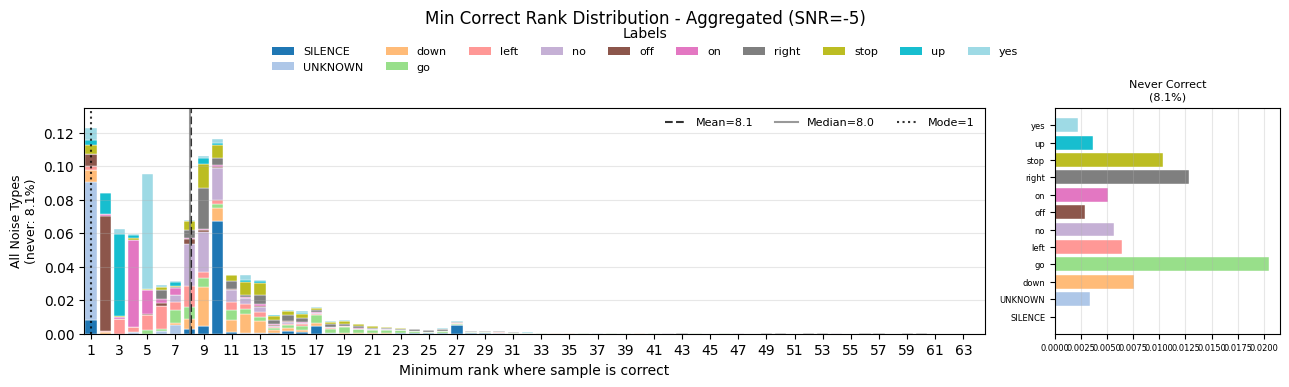

/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_8174/3548684709.py:87: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, n_labels) if stack_by_label else None



=== Stats per noise type for SNR=0 (mode: first correct) ===
  Note: nv_stable is % of ever_correct samples (marked with *)
  doing_the_dishes.wav: 287/4515 never correct (6.4%)
  dude_miaowing.wav: 196/4515 never correct (4.3%)
  exercise_bike.wav: 209/4515 never correct (4.6%)
  pink_noise.wav: 156/4515 never correct (3.5%)
  running_tap.wav: 179/4515 never correct (4.0%)
  white_noise.wav: 213/4515 never correct (4.7%)



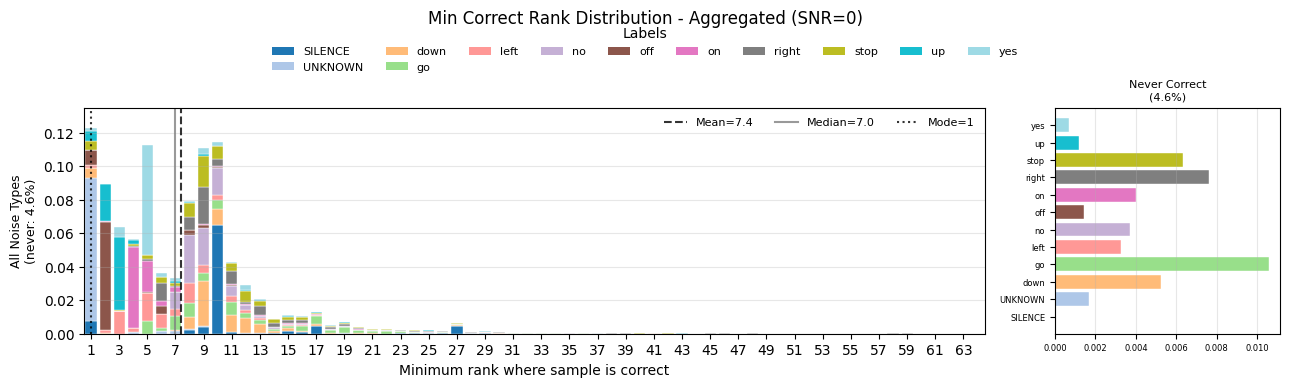

/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_8174/3548684709.py:87: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, n_labels) if stack_by_label else None



=== Stats per noise type for SNR=5 (mode: first correct) ===
  Note: nv_stable is % of ever_correct samples (marked with *)
  doing_the_dishes.wav: 178/4515 never correct (3.9%)
  dude_miaowing.wav: 134/4515 never correct (3.0%)
  exercise_bike.wav: 148/4515 never correct (3.3%)
  pink_noise.wav: 128/4515 never correct (2.8%)
  running_tap.wav: 133/4515 never correct (2.9%)
  white_noise.wav: 153/4515 never correct (3.4%)



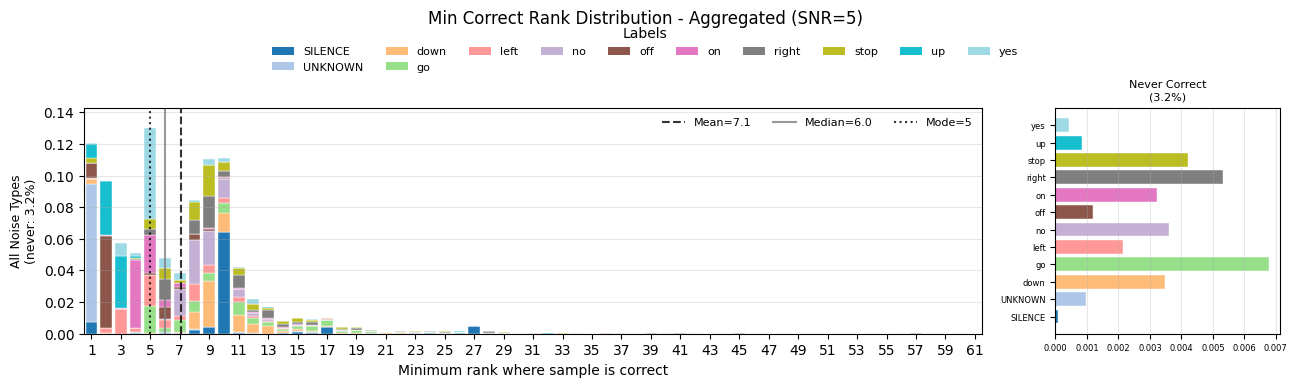

/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_8174/3548684709.py:87: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, n_labels) if stack_by_label else None



=== Stats per noise type for SNR=10 (mode: first correct) ===
  Note: nv_stable is % of ever_correct samples (marked with *)
  doing_the_dishes.wav: 136/4515 never correct (3.0%)
  dude_miaowing.wav: 116/4515 never correct (2.6%)
  exercise_bike.wav: 117/4515 never correct (2.6%)
  pink_noise.wav: 113/4515 never correct (2.5%)
  running_tap.wav: 127/4515 never correct (2.8%)
  white_noise.wav: 117/4515 never correct (2.6%)



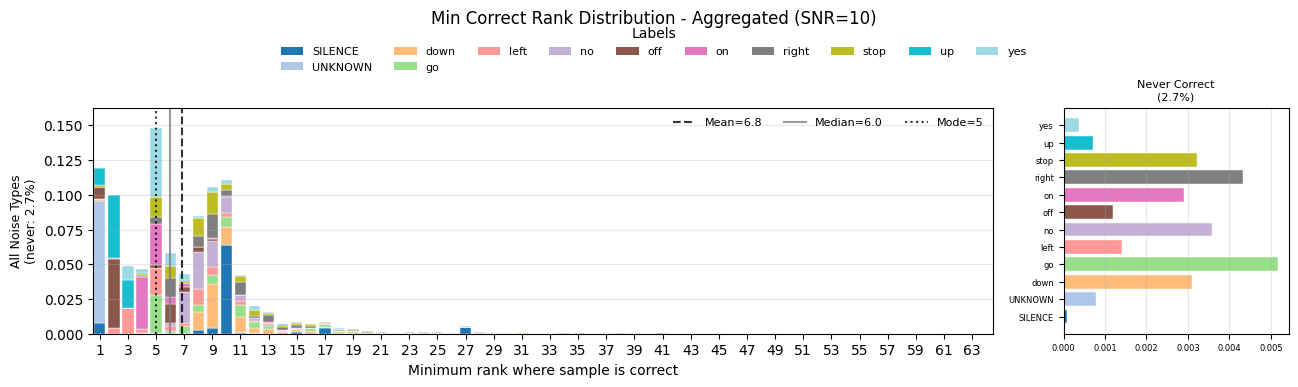

/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_8174/3548684709.py:87: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, n_labels) if stack_by_label else None



=== Stats per noise type for SNR=15 (mode: first correct) ===
  Note: nv_stable is % of ever_correct samples (marked with *)
  doing_the_dishes.wav: 114/4515 never correct (2.5%)
  dude_miaowing.wav: 114/4515 never correct (2.5%)
  exercise_bike.wav: 100/4515 never correct (2.2%)
  pink_noise.wav: 102/4515 never correct (2.3%)
  running_tap.wav: 119/4515 never correct (2.6%)
  white_noise.wav: 106/4515 never correct (2.3%)



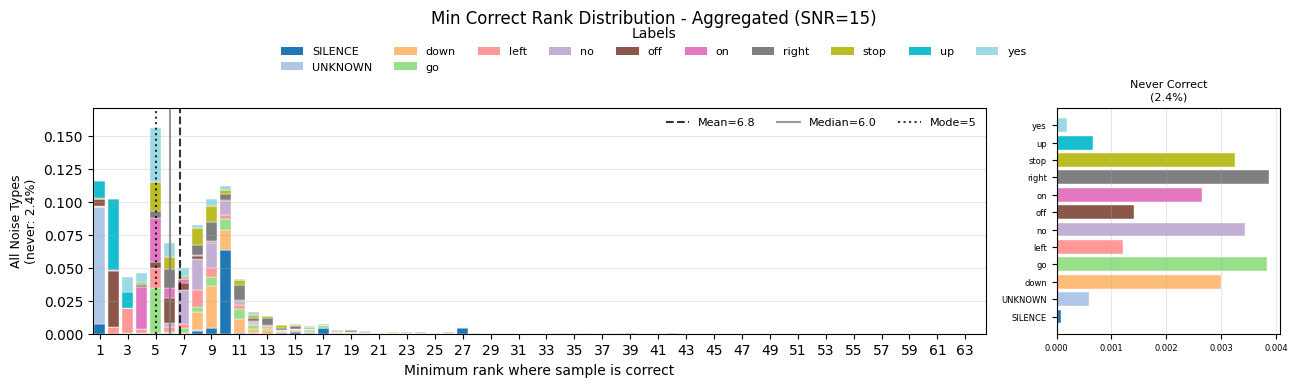

/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_8174/3548684709.py:87: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, n_labels) if stack_by_label else None



=== Stats per noise type for SNR=inf (mode: first correct) ===
  Note: nv_stable is % of ever_correct samples (marked with *)
  doing_the_dishes.wav: 93/4515 never correct (2.1%)
  dude_miaowing.wav: 93/4515 never correct (2.1%)
  exercise_bike.wav: 94/4515 never correct (2.1%)
  pink_noise.wav: 93/4515 never correct (2.1%)
  running_tap.wav: 94/4515 never correct (2.1%)
  white_noise.wav: 93/4515 never correct (2.1%)



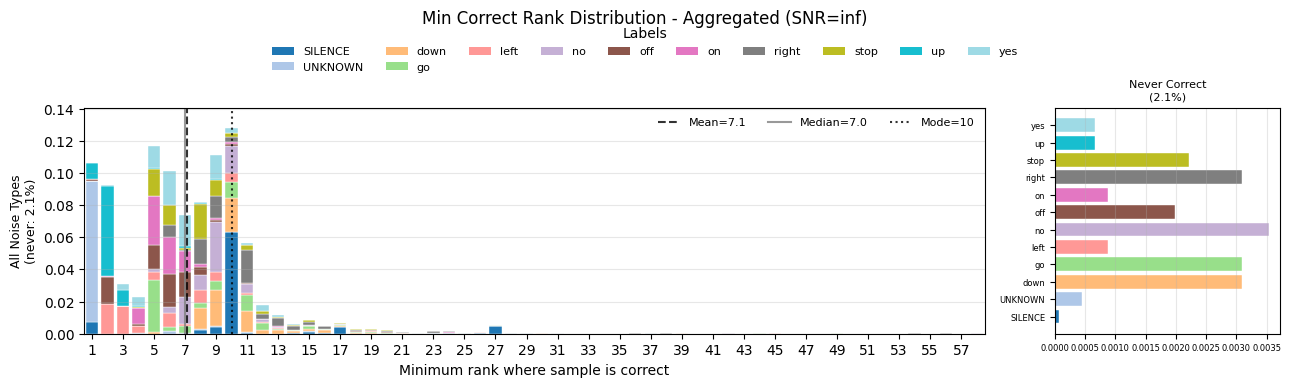

In [20]:
# Example: Plot min correct rank distribution by noise type for a specific SNR
# Change snr_value to the SNR you want to analyze
snr_value = float("inf")  # Adjust this to your desired SNR value
snr_values = [-5, 0, 5, 10, 15, float('inf')] 
#snr_values = [-5,float('inf')] 
for snr_value in snr_values:

    per_sample_by_noise = plot_min_correct_rank_by_noise_type(
        df=df_for_viz,
        snr_value=snr_value,
        normalize=True,
        stack_by_label=True,  # Set to False for simple bars without label stacking
        require_stable=False,  # Set to True to find min rank where sample STAYS correct
        aggregate_noise=True,  # Set to True for single aggregated plot across all noise types
    )

In [8]:
def plot_min_correct_rank_by_label(
    df: pd.DataFrame,
    snr_value: float,
    *,
    snr_col: str = "snr_eval",
    rank_col: str = "rank",
    correct_col: str = "correct",
    id_col: str = "id",
    label_col: str = "label",
    noise_col: str = "noise_file",
    normalize: bool = True,
    figsize_per_plot: Tuple[float, float] = (10, 2),
    stack_by_noise: bool = True,
    cmap_name: str = "tab10",
):
    """
    For a given SNR value, plot the histogram of minimum rank where each sample
    becomes correct, with one subplot per label/class.
    
    Plots are stacked vertically with a shared x-axis to easily visualize
    distribution shifts across different classes.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with per-sample results
    snr_value : float
        The SNR value to filter on
    snr_col : str
        Column name for SNR values
    rank_col : str
        Column name for rank values
    correct_col : str
        Column name for correctness (bool or 0/1)
    id_col : str
        Column name for sample ID
    label_col : str
        Column name for the class label
    noise_col : str
        Column name for noise type / validation set identifier
    normalize : bool
        If True, show probability; if False, show counts
    figsize_per_plot : tuple
        (width, height) per subplot
    stack_by_noise : bool
        If True, stack bars by noise type with different colors
    cmap_name : str
        Colormap name for noise type colors
        
    Returns
    -------
    per_sample : pd.DataFrame
        DataFrame with min_rank per sample, label, and noise type
    """
    
    needed = {snr_col, rank_col, correct_col, id_col, label_col}
    if stack_by_noise:
        needed.add(noise_col)
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")
    
    # Filter to the specified SNR
    df_snr = df[df[snr_col] == snr_value].copy()
    if len(df_snr) == 0:
        raise ValueError(f"No data found for SNR={snr_value}")
    
    # Keep only correct predictions
    correct_df = df_snr[df_snr[correct_col].astype(bool)]
    
    # Get unique noise types in sorted order (consistent across all plots)
    all_noise_types = sorted(df_snr[noise_col].unique()) if stack_by_noise else []
    n_noise_types = len(all_noise_types)
    
    # Create color mapping for noise types
    cmap = plt.cm.get_cmap(cmap_name, n_noise_types) if stack_by_noise else None
    noise_colors = {nt: cmap(i) for i, nt in enumerate(all_noise_types)} if stack_by_noise else {}
    
    # Min rank where sample becomes correct (per label and noise type)
    if stack_by_noise:
        min_rank_df = (
            correct_df
            .groupby([label_col, noise_col, id_col])[rank_col]
            .min()
            .reset_index(name="min_rank")
        )
    else:
        # Take min across all noise types for each sample
        min_rank_df = (
            correct_df
            .groupby([label_col, id_col])[rank_col]
            .min()
            .reset_index(name="min_rank")
        )
    
    # All unique samples per label (and noise type if stacking)
    if stack_by_noise:
        all_samples = df_snr[[label_col, noise_col, id_col]].drop_duplicates()
    else:
        all_samples = df_snr[[label_col, id_col]].drop_duplicates()
    
    per_sample = all_samples.merge(
        min_rank_df,
        on=[label_col, noise_col, id_col] if stack_by_noise else [label_col, id_col],
        how="left",
    )
    
    # Compute global x-axis limits
    all_ranks = per_sample["min_rank"].dropna().astype(int)
    if len(all_ranks) == 0:
        print("No correct samples found for this SNR")
        return per_sample
    
    xmin, xmax = int(all_ranks.min()), int(all_ranks.max())
    all_x_vals = list(range(xmin, xmax + 1))
    
    # Compute mean across all labels (per sample id, averaged across noise types)
    if stack_by_noise:
        mean_per_sample = (
            per_sample
            .groupby([noise_col, id_col])["min_rank"]
            .mean()
            .reset_index(name="min_rank")
        )
        mean_per_sample[label_col] = "MEAN (all labels)"
    else:
        mean_per_sample = (
            per_sample
            .groupby(id_col)["min_rank"]
            .mean()
            .reset_index(name="min_rank")
        )
        mean_per_sample[label_col] = "MEAN (all labels)"
    
    # Combine individual labels + mean
    per_sample_with_mean = pd.concat([per_sample, mean_per_sample], ignore_index=True)
    
    # Compute global y-axis limit (include mean in calculation)
    ymax = 0.0
    labels = sorted(per_sample[label_col].unique())
    labels_with_mean = labels + ["MEAN (all labels)"]
    
    for label in labels_with_mean:
        sub = per_sample_with_mean[per_sample_with_mean[label_col] == label]
        ranks = sub["min_rank"].dropna()
        if len(ranks) == 0:
            continue
        ranks_int = ranks.round().astype(int)
        counts = ranks_int.value_counts().sort_index()
        y = counts.to_numpy()
        if normalize:
            y = y / y.sum()
        ymax = max(ymax, float(y.max()))
    
    # Create vertically stacked subplots with shared x-axis
    # +1 for the mean plot
    n_plots = len(labels) + 1
    fig, axes = plt.subplots(
        n_plots,
        1,
        figsize=(figsize_per_plot[0], figsize_per_plot[1] * n_plots),
        sharex=True,
        sharey=True,
    )
    
    if n_plots == 1:
        axes = [axes]
    
    xticks = list(range(xmin, xmax + 1, 2))
    
    def plot_stacked_bars(ax, sub_df, is_mean=False):
        """Helper to plot stacked bars by noise type."""
        ranks = sub_df["min_rank"].dropna()
        if len(ranks) == 0:
            ax.text(0.5, 0.5, "No correct samples",
                    ha="center", va="center", transform=ax.transAxes)
            return
        
        # Only convert non-NaN values to int to avoid IntCastingNaNError
        sub_df = sub_df.copy()
        if is_mean:
            sub_df.loc[sub_df["min_rank"].notna(), "min_rank_int"] = sub_df.loc[sub_df["min_rank"].notna(), "min_rank"].round().astype(int)
        else:
            sub_df.loc[sub_df["min_rank"].notna(), "min_rank_int"] = sub_df.loc[sub_df["min_rank"].notna(), "min_rank"].astype(int)
        
        # Get total count for normalization
        total_correct = len(sub_df[sub_df["min_rank"].notna()])
        
        # Build stacked bar data
        bottom = np.zeros(len(all_x_vals))
        
        for noise_type in all_noise_types:
            noise_sub = sub_df[(sub_df[noise_col] == noise_type) & (sub_df["min_rank"].notna())]
            counts = noise_sub["min_rank_int"].value_counts()
            
            heights = np.zeros(len(all_x_vals))
            for i, x_val in enumerate(all_x_vals):
                if x_val in counts.index:
                    heights[i] = counts[x_val]
            
            if normalize and total_correct > 0:
                heights = heights / total_correct
            
            # Shorten noise type name for legend
            noise_label = noise_type.split("/")[-1] if "/" in str(noise_type) else str(noise_type)
            
            ax.bar(
                all_x_vals,
                heights,
                bottom=bottom,
                color=noise_colors[noise_type],
                edgecolor="white",
                linewidth=0.3,
                width=0.8,
                label=noise_label,
            )
            bottom += heights
        
        # Statistics
        mean_rank = float(ranks.mean())
        median_rank = float(ranks.median())
        ranks_int = ranks.round().astype(int) if is_mean else ranks.astype(int)
        mode_rank = int(ranks_int.mode().iloc[0])
        
        ax.axvline(mean_rank, linestyle="--", linewidth=1.5,
                   label=f"Mean={mean_rank:.1f}", color="black", alpha=0.8)
        ax.axvline(median_rank, linestyle="-", linewidth=1.5,
                   label=f"Median={median_rank:.1f}", color="gray", alpha=0.8)
        ax.axvline(mode_rank, linestyle=":", linewidth=1.5,
                   label=f"Mode={mode_rank}", color="black", alpha=0.8)
    
    def plot_simple_bars(ax, sub_df, color, is_mean=False):
        """Helper to plot simple (non-stacked) bars."""
        ranks = sub_df["min_rank"].dropna()
        if len(ranks) == 0:
            ax.text(0.5, 0.5, "No correct samples",
                    ha="center", va="center", transform=ax.transAxes)
            return
        
        if is_mean:
            ranks_int = ranks.round().astype(int)
        else:
            ranks_int = ranks.astype(int)
        
        counts = ranks_int.value_counts().sort_index()
        x = counts.index.to_numpy()
        y = counts.to_numpy()
        
        if normalize:
            y = y / y.sum()
        
        ax.bar(x, y, color=color, alpha=0.7, edgecolor="black", linewidth=0.5)
        
        mean_rank = float(ranks.mean())
        median_rank = float(ranks.median())
        mode_rank = int(ranks_int.mode().iloc[0])
        
        ax.axvline(mean_rank, linestyle="--", linewidth=1.5,
                   label=f"Mean={mean_rank:.1f}", color="C1")
        ax.axvline(median_rank, linestyle="-", linewidth=1.5,
                   label=f"Median={median_rank:.1f}", color="C2")
        ax.axvline(mode_rank, linestyle=":", linewidth=1.5,
                   label=f"Mode={mode_rank}", color="C3")
        
        ax.legend(loc="upper right", frameon=False, fontsize=8, ncol=3)
    
    # Collect never-correct percentages for computing average
    never_pct_list = []
    
    # Plot individual labels
    for ax, label in zip(axes[:-1], labels):
        sub = per_sample[per_sample[label_col] == label]
        
        # Count unique samples for this label
        if stack_by_noise:
            # Each sample appears once per noise type, so count unique ids
            unique_samples = sub[id_col].nunique()
            # Never correct = samples that are never correct for ANY noise type
            never_any = sub.groupby(id_col)["min_rank"].apply(lambda x: x.isna().all()).sum()
            never_pct = 100.0 * never_any / unique_samples if unique_samples else 0.0
            total = unique_samples
        else:
            total = len(sub)
            never = int(sub["min_rank"].isna().sum())
            never_pct = 100.0 * never / total if total else 0.0
        
        never_pct_list.append(never_pct)
        
        if stack_by_noise:
            plot_stacked_bars(ax, sub, is_mean=False)
        else:
            plot_simple_bars(ax, sub, "C0", is_mean=False)
        
        ax.set_ylabel(f"{label}\n(n={total}, never: {never_pct:.1f}%)", fontsize=9)
        
        ax.set_xlim(xmin - 0.5, xmax + 0.5)
        ax.set_ylim(0, ymax * 1.1)
        ax.grid(axis="y", alpha=0.3)
    
    # Plot mean across all labels (last subplot)
    ax_mean = axes[-1]
    
    # Use average of per-label never percentages
    avg_never_pct = np.mean(never_pct_list) if never_pct_list else 0.0
    
    if stack_by_noise:
        plot_stacked_bars(ax_mean, mean_per_sample, is_mean=True)
    else:
        plot_simple_bars(ax_mean, mean_per_sample, "C4", is_mean=True)
    
    ax_mean.set_ylabel(f"MEAN\n(avg never: {avg_never_pct:.1f}%)", fontsize=9, fontweight="bold")
    ax_mean.set_xlim(xmin - 0.5, xmax + 0.5)
    ax_mean.set_ylim(0, ymax * 1.1)
    ax_mean.grid(axis="y", alpha=0.3)
    
    # Set x-axis label and ticks on bottom plot
    axes[-1].set_xlabel("Minimum rank where sample is correct", fontsize=10)
    axes[-1].set_xticks(xticks)
    
    # Title
    fig.suptitle(
        f"Min Correct Rank Distribution by Label (SNR={snr_value})",
        fontsize=12,
        y=1.01,
    )
    
    # Add a legend for noise types (outside the plot area)
    if stack_by_noise:
        from matplotlib.patches import Patch
        legend_handles = [
            Patch(facecolor=noise_colors[nt], 
                  label=nt.split("/")[-1] if "/" in str(nt) else str(nt)) 
            for nt in all_noise_types
        ]
        # Add stat line handles
        legend_handles.extend([
            plt.Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Mean"),
            plt.Line2D([0], [0], color="gray", linestyle="-", linewidth=1.5, label="Median"),
            plt.Line2D([0], [0], color="black", linestyle=":", linewidth=1.5, label="Mode"),
        ])
        fig.legend(
            handles=legend_handles,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.0),
            ncol=min(10, n_noise_types + 3),
            fontsize=8,
            frameon=False,
            title="Noise Types & Stats",
        )
    
    plt.tight_layout(rect=[0, 0, 1, 0.96] if stack_by_noise else [0, 0, 1, 1])
    plt.show()
    
    return per_sample

/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_8174/3056090774.py:76: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, n_noise_types) if stack_by_noise else None


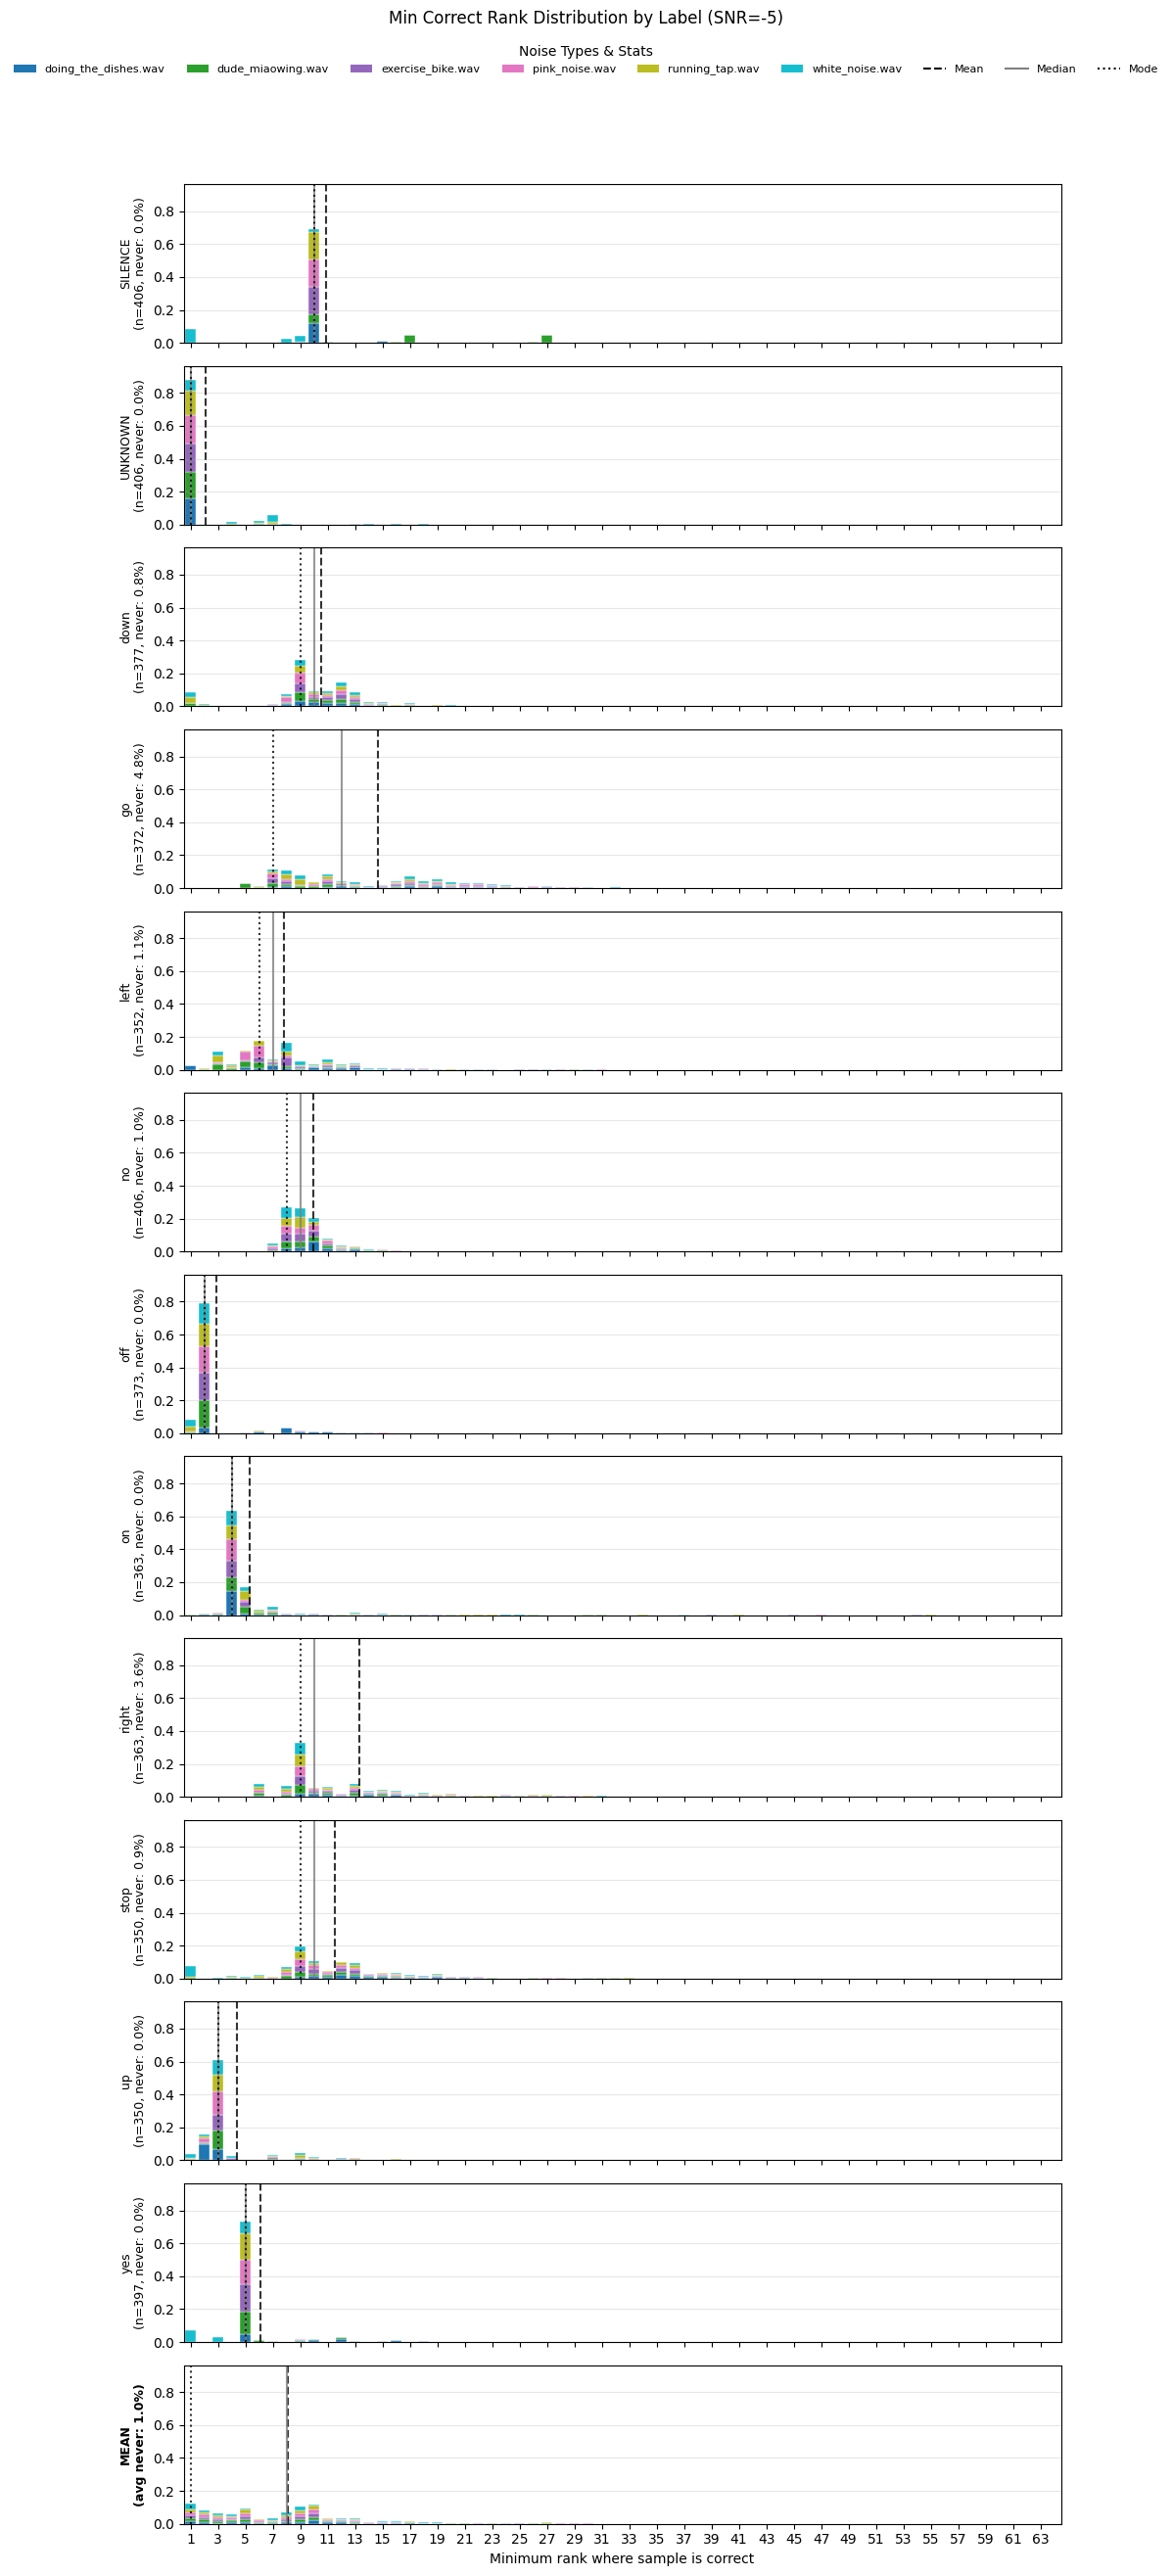

In [9]:
# Example: Plot min correct rank distribution by label for a specific SNR
snr_value = -5  # Adjust this to your desired SNR value

per_sample_by_label = plot_min_correct_rank_by_label(
    df=df_for_viz,
    snr_value=snr_value,
    normalize=True,
    stack_by_noise=True,  # Set to False for simple bars without noise stacking
)

In [10]:
def plot_min_correct_rank_grid_label_vs_noise(
    df: pd.DataFrame,
    snr_value: float,
    *,
    snr_col: str = "snr_eval",
    rank_col: str = "rank",
    correct_col: str = "correct",
    id_col: str = "id",
    label_col: str = "label",
    noise_col: str = "noise_file",
    normalize: bool = True,
    figsize_per_cell: Tuple[float, float] = (3, 2),
    color: str = "C0",
):
    """
    For a given SNR value, plot a grid of min correct rank distributions where:
      - Rows = different labels/classes
      - Columns = different noise types
    
    All subplots share the same x and y axes for easy comparison.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with per-sample results
    snr_value : float
        The SNR value to filter on
    snr_col : str
        Column name for SNR values
    rank_col : str
        Column name for rank values
    correct_col : str
        Column name for correctness (bool or 0/1)
    id_col : str
        Column name for sample ID
    label_col : str
        Column name for the class label
    noise_col : str
        Column name for noise type / validation set identifier
    normalize : bool
        If True, show probability; if False, show counts
    figsize_per_cell : tuple
        (width, height) per subplot cell
    color : str
        Bar color
        
    Returns
    -------
    per_sample : pd.DataFrame
        DataFrame with min_rank per sample, label, and noise type
    """
    
    needed = {snr_col, rank_col, correct_col, id_col, label_col, noise_col}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")
    
    # Filter to the specified SNR
    df_snr = df[df[snr_col] == snr_value].copy()
    if len(df_snr) == 0:
        raise ValueError(f"No data found for SNR={snr_value}")
    
    # Keep only correct predictions
    correct_df = df_snr[df_snr[correct_col].astype(bool)]
    
    # Get unique labels and noise types
    labels = sorted(df_snr[label_col].unique())
    noise_types = sorted(df_snr[noise_col].unique())
    n_labels = len(labels)
    n_noise_types = len(noise_types)
    
    # Shorten noise type names for display
    noise_labels = [nt.split("/")[-1] if "/" in str(nt) else str(nt) for nt in noise_types]
    
    # Min rank where sample becomes correct (per label and noise type)
    min_rank_df = (
        correct_df
        .groupby([label_col, noise_col, id_col])[rank_col]
        .min()
        .reset_index(name="min_rank")
    )
    
    # All unique samples per label and noise type
    all_samples = df_snr[[label_col, noise_col, id_col]].drop_duplicates()
    
    per_sample = all_samples.merge(
        min_rank_df,
        on=[label_col, noise_col, id_col],
        how="left",
    )
    
    # Compute global x-axis limits
    all_ranks = per_sample["min_rank"].dropna().astype(int)
    if len(all_ranks) == 0:
        print("No correct samples found for this SNR")
        return per_sample
    
    xmin, xmax = int(all_ranks.min()), int(all_ranks.max())
    
    # Compute global y-axis limit
    ymax = 0.0
    for label in labels:
        for noise_type in noise_types:
            sub = per_sample[(per_sample[label_col] == label) & (per_sample[noise_col] == noise_type)]
            ranks = sub["min_rank"].dropna()
            if len(ranks) == 0:
                continue
            ranks_int = ranks.astype(int)
            counts = ranks_int.value_counts().sort_index()
            y = counts.to_numpy()
            if normalize:
                y = y / y.sum()
            ymax = max(ymax, float(y.max()))
    
    # Create grid of subplots
    fig, axes = plt.subplots(
        n_labels,
        n_noise_types,
        figsize=(figsize_per_cell[0] * n_noise_types, figsize_per_cell[1] * n_labels),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    
    xticks = list(range(xmin, xmax + 1, 2))
    
    # Plot each cell
    for row_idx, label in enumerate(labels):
        for col_idx, noise_type in enumerate(noise_types):
            ax = axes[row_idx, col_idx]
            
            sub = per_sample[(per_sample[label_col] == label) & (per_sample[noise_col] == noise_type)]
            ranks = sub["min_rank"].dropna()
            
            total = len(sub)
            never = int(sub["min_rank"].isna().sum())
            never_pct = 100.0 * never / total if total else 0.0
            
            if len(ranks) > 0:
                ranks_int = ranks.astype(int)
                counts = ranks_int.value_counts().sort_index()
                x = counts.index.to_numpy()
                y = counts.to_numpy()
                
                if normalize:
                    y = y / y.sum()
                
                ax.bar(x, y, color=color, alpha=0.7, edgecolor="black", linewidth=0.3)
                
                # Statistics - add mean line
                mean_rank = float(ranks.mean())
                ax.axvline(mean_rank, linestyle="--", linewidth=1, color="red", alpha=0.8)
            else:
                ax.text(0.5, 0.5, "No correct",
                        ha="center", va="center", transform=ax.transAxes, fontsize=7)
            
            # Add never percentage as text annotation
            ax.text(0.98, 0.98, f"nv:{never_pct:.0f}%",
                    ha="right", va="top", transform=ax.transAxes, fontsize=6,
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
            
            ax.set_xlim(xmin - 0.5, xmax + 0.5)
            ax.set_ylim(0, ymax * 1.1)
            ax.grid(axis="y", alpha=0.3)
            
            # Row labels (left side)
            if col_idx == 0:
                ax.set_ylabel(label, fontsize=9, fontweight="bold")
            
            # Column labels (top)
            if row_idx == 0:
                ax.set_title(noise_labels[col_idx], fontsize=9, fontweight="bold")
            
            # X ticks on bottom row only
            if row_idx == n_labels - 1:
                ax.set_xticks(xticks)
                ax.tick_params(axis="x", labelsize=7, rotation=45)
    
    # Global labels
    fig.text(0.5, 0.02, "Minimum rank where sample is correct", ha="center", fontsize=10)
    fig.text(0.02, 0.5, "Probability" if normalize else "Count", 
             va="center", rotation="vertical", fontsize=10)
    
    # Title
    fig.suptitle(
        f"Min Correct Rank Distribution: Label × Noise Type (SNR={snr_value})",
        fontsize=12,
        y=0.98,
    )
    
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.96])
    plt.show()
    
    return per_sample

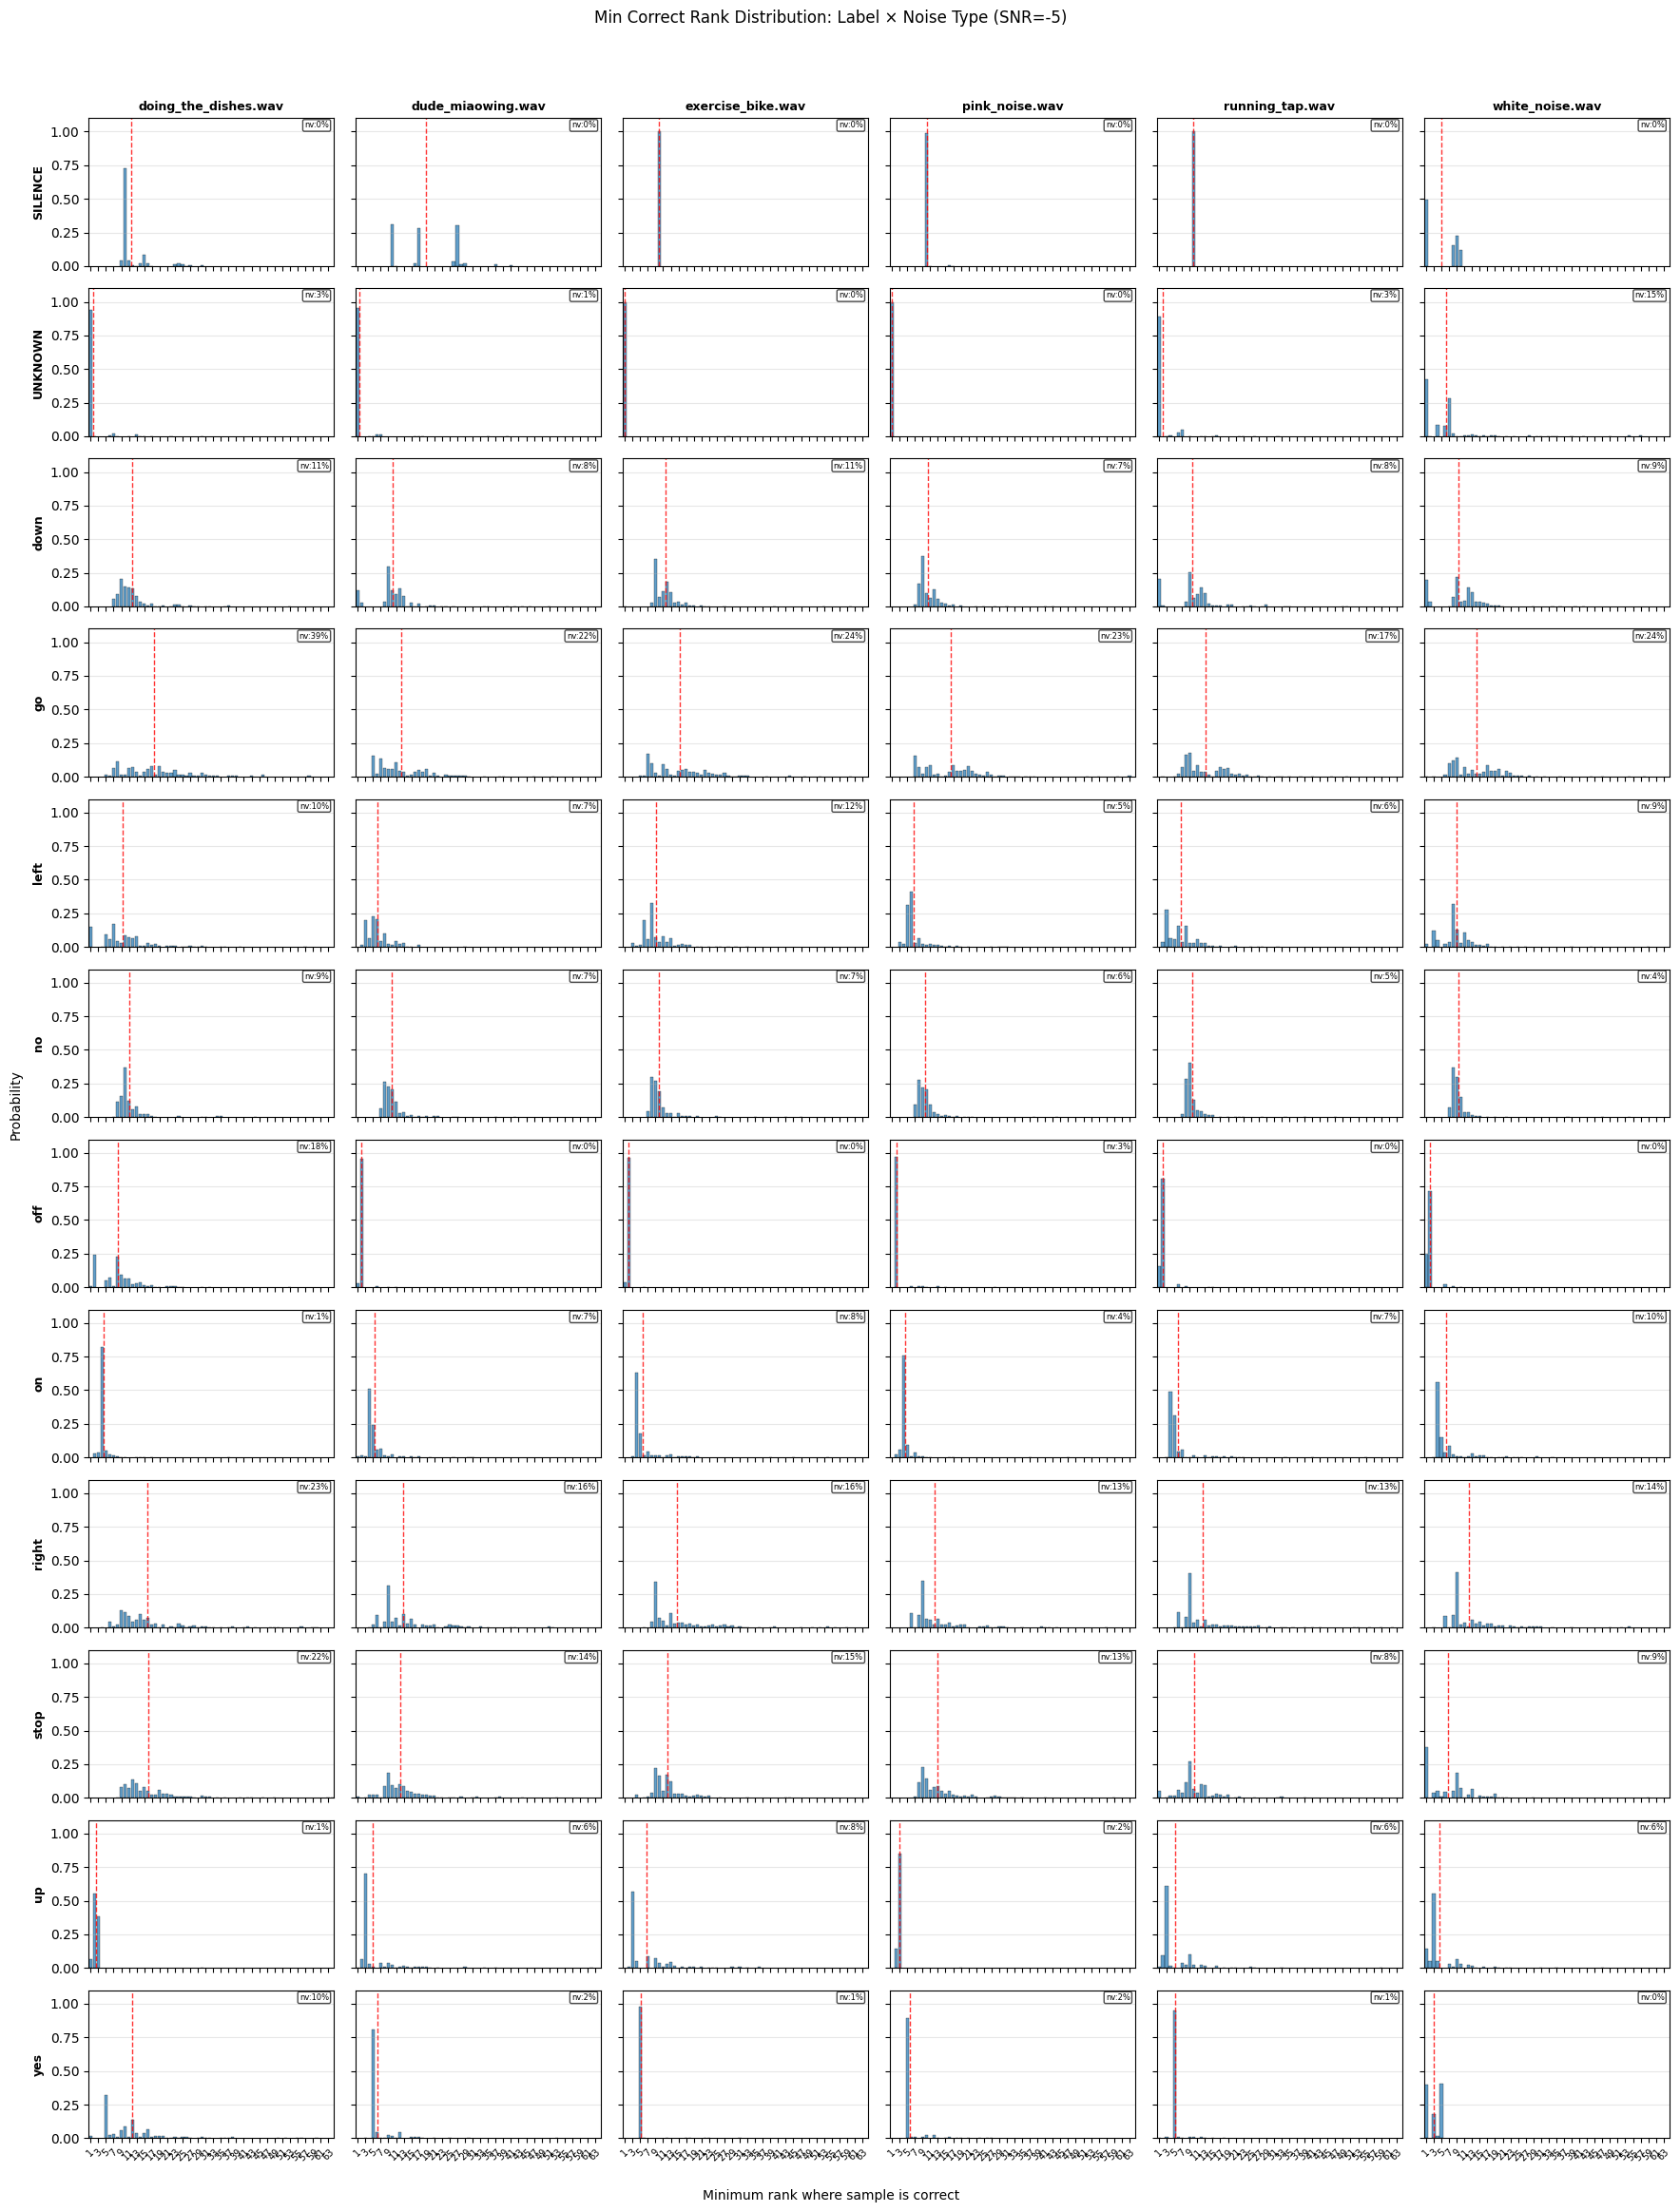

In [11]:
# Example: Plot min correct rank distribution grid (labels × noise types) for a specific SNR
snr_value = -5  # Adjust this to your desired SNR value

per_sample_grid = plot_min_correct_rank_grid_label_vs_noise(
    df=df_for_viz,
    snr_value=snr_value,
    normalize=True,
)

In [12]:
def summarize_min_correct_rank_stats(
    df: pd.DataFrame,
    snr_values: List[float],
    *,
    snr_col: str = "snr_eval",
    rank_col: str = "rank",
    correct_col: str = "correct",
    id_col: str = "id",
    label_col: str = "label",
    noise_col: str = "noise_file",
    stats: List[str] = ["Mean", "Mode", "P95", "Never%"],
):
    """
    Generate summary statistics for min correct rank across multiple SNR values.
    Displays each statistic as a table with Labels as rows and (Noise, SNR) as columns.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with per-sample results
    snr_values : List[float]
        List of SNR values to include in the summary
    snr_col : str
        Column name for SNR values
    rank_col : str
        Column name for rank values
    correct_col : str
        Column name for correctness (bool or 0/1)
    id_col : str
        Column name for sample ID
    label_col : str
        Column name for the class label
    noise_col : str
        Column name for noise type / validation set identifier
    stats : List[str]
        Which statistics to display. Options: "Mean", "Median", "Mode", "P95", "Never%"
        
    Returns
    -------
    summary_df : pd.DataFrame
        Full summary dataframe with all statistics for all SNR × Label × Noise combinations
    """
    
    needed = {snr_col, rank_col, correct_col, id_col, label_col, noise_col}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")
    
    all_summary_rows = []
    
    for snr_value in snr_values:
        # Filter to the specified SNR
        df_snr = df[df[snr_col] == snr_value].copy()
        if len(df_snr) == 0:
            print(f"Warning: No data found for SNR={snr_value}, skipping...")
            continue
        
        # Keep only correct predictions
        correct_df = df_snr[df_snr[correct_col].astype(bool)]
        
        # Get unique labels and noise types
        labels = sorted(df_snr[label_col].unique())
        noise_types = sorted(df_snr[noise_col].unique())
        
        # Min rank where sample becomes correct (per label and noise type)
        min_rank_df = (
            correct_df
            .groupby([label_col, noise_col, id_col])[rank_col]
            .min()
            .reset_index(name="min_rank")
        )
        
        # All unique samples per label and noise type
        all_samples = df_snr[[label_col, noise_col, id_col]].drop_duplicates()
        
        per_sample = all_samples.merge(
            min_rank_df,
            on=[label_col, noise_col, id_col],
            how="left",
        )
        
        # Compute stats for each label × noise combination
        for label in labels:
            for noise_type in noise_types:
                sub = per_sample[(per_sample[label_col] == label) & (per_sample[noise_col] == noise_type)]
                ranks = sub["min_rank"].dropna()
                
                total = len(sub)
                never = int(sub["min_rank"].isna().sum())
                never_pct = 100.0 * never / total if total else 0.0
                
                noise_short = noise_type.split("/")[-1] if "/" in str(noise_type) else str(noise_type)
                
                row = {
                    "SNR": snr_value,
                    "Label": label,
                    "Noise": noise_short,
                    "N": total,
                    "Never%": round(never_pct, 1),
                }
                
                if len(ranks) > 0:
                    ranks_int = ranks.astype(int)
                    row["Mean"] = round(float(ranks.mean()), 2)
                    row["Median"] = round(float(ranks.median()), 2)
                    row["Mode"] = int(ranks_int.mode().iloc[0])
                    row["P95"] = round(float(ranks.quantile(0.95)), 2)
                else:
                    row["Mean"] = None
                    row["Median"] = None
                    row["Mode"] = None
                    row["P95"] = None
                
                all_summary_rows.append(row)
    
    summary_df = pd.DataFrame(all_summary_rows)
    
    if len(summary_df) == 0:
        print("No data found for any of the specified SNR values.")
        return summary_df
    
    # Get unique noise types for column ordering
    noise_types_short = summary_df["Noise"].unique().tolist()
    
    # Print summary tables for each statistic
    print(f"\n{'='*100}")
    print(f"  MIN CORRECT RANK STATISTICS: Comparing SNR values {snr_values}")
    print(f"{'='*100}")
    
    for stat in stats:
        if stat not in summary_df.columns:
            print(f"\nWarning: Statistic '{stat}' not available, skipping...")
            continue
        
        print(f"\n{'─'*100}")
        print(f"  {stat}")
        print(f"{'─'*100}")
        
        # Create a multi-level pivot: Label as index, (Noise, SNR) as columns
        pivot = summary_df.pivot_table(
            index="Label",
            columns=["Noise", "SNR"],
            values=stat,
            aggfunc="first"
        )
        
        # Reorder columns to group by noise type first, then SNR
        if len(snr_values) > 1:
            new_cols = []
            for noise in noise_types_short:
                for snr in sorted(snr_values):
                    if (noise, snr) in pivot.columns:
                        new_cols.append((noise, snr))
            pivot = pivot[new_cols]
        
        # Format the output
        print(pivot.to_string())
    
    print(f"\n{'='*100}\n")
    
    return summary_df

In [13]:
# Example: Compare min correct rank statistics across multiple SNR values
snr_values_to_compare = [-5, 0, 5, float('inf')]  # Adjust to your desired SNR values

summary_multi_snr = summarize_min_correct_rank_stats(
    df=df_for_viz,
    snr_values=snr_values_to_compare,
    stats=["Mean", "Mode", "P95", "Never%"],  # Choose which stats to display
)


  MIN CORRECT RANK STATISTICS: Comparing SNR values [-5, 0, 5, inf]

────────────────────────────────────────────────────────────────────────────────────────────────────
  Mean
────────────────────────────────────────────────────────────────────────────────────────────────────
Noise   doing_the_dishes.wav                      dude_miaowing.wav                      exercise_bike.wav                      pink_noise.wav                      running_tap.wav                      white_noise.wav                     
SNR                     -5.0    0.0    5.0    inf              -5.0    0.0    5.0    inf              -5.0    0.0    5.0    inf           -5.0    0.0    5.0    inf            -5.0    0.0    5.0    inf            -5.0    0.0    5.0    inf
Label                                                                                                                                                                                                                                        
SILENCE

In [18]:
def plot_rank_vs_acc_per_label(
    df: pd.DataFrame,
    snr_values: List[float],
    *,
    snr_col: str = "snr_eval",
    rank_col: str = "rank",
    correct_col: str = "correct",
    label_col: str = "label",
    noise_col: str = "noise_file",
    figsize: Tuple[float, float] = (10, 6),
    cmap_name: str = "tab20",
    marker: str = "o",
    highlight_labels: Optional[List[str]] = None,
    show_mean: bool = True,
):
    """
    For a list of SNR values, plot accuracy vs rank with one line per label.
    Each SNR gets its own separate figure (one plot at a time).
    Accuracy is averaged over all noise types for each (label, rank) combination.
    
    This helps visualize if different labels follow different accuracy curves
    as rank increases, and how these curves change across SNR levels.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with per-sample results
    snr_values : List[float]
        List of SNR values to plot (one figure per SNR)
    snr_col : str
        Column name for SNR values
    rank_col : str
        Column name for rank values
    correct_col : str
        Column name for correctness (bool or 0/1)
    label_col : str
        Column name for the class label
    noise_col : str
        Column name for noise type / validation set identifier
    figsize : tuple
        Figure size (width, height) for each plot
    cmap_name : str
        Colormap name for label colors
    marker : str
        Marker style for the lines
    highlight_labels : list or None
        If provided, only these labels will be shown with full opacity;
        others will be shown with reduced opacity
    show_mean : bool
        If True, show a thick black line for the mean across all labels
        
    Returns
    -------
    summary : pd.DataFrame
        DataFrame with accuracy per (snr, label, rank) combination
    """
    
    needed = {snr_col, rank_col, correct_col, label_col}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")
    
    n_snr = len(snr_values)
    if n_snr == 0:
        raise ValueError("snr_values must contain at least one value")
    
    # Get global labels for consistent coloring across all plots
    all_labels = sorted(df[label_col].unique())
    n_labels = len(all_labels)
    
    # Create color mapping for labels (consistent across all plots)
    cmap = plt.cm.get_cmap(cmap_name, n_labels)
    label_colors = {label: cmap(i) for i, label in enumerate(all_labels)}
    
    all_summaries = []
    
    for snr_value in snr_values:
        # Filter to the specified SNR
        df_snr = df[df[snr_col] == snr_value].copy()
        if len(df_snr) == 0:
            print(f"No data found for SNR={snr_value}, skipping...")
            continue
        
        # Get ranks for this SNR
        ranks = sorted(df_snr[rank_col].unique())
        
        # Compute accuracy per (label, rank), averaged over all noise types
        acc_per_label_rank = (
            df_snr
            .groupby([label_col, rank_col])[correct_col]
            .mean()
            .mul(100)
            .reset_index(name="accuracy")
        )
        acc_per_label_rank[snr_col] = snr_value
        all_summaries.append(acc_per_label_rank)
        
        # Also compute overall mean across all labels for each rank
        mean_acc_per_rank = (
            df_snr
            .groupby(rank_col)[correct_col]
            .mean()
            .mul(100)
            .reset_index(name="accuracy")
        )
        
        # Create a new figure for this SNR
        fig, ax = plt.subplots(figsize=figsize)
        
        # Plot each label
        for label in all_labels:
            sub = acc_per_label_rank[acc_per_label_rank[label_col] == label]
            if len(sub) == 0:
                continue
            
            # Determine opacity based on highlight_labels
            if highlight_labels is not None:
                alpha = 1.0 if label in highlight_labels else 0.2
                linewidth = 2.0 if label in highlight_labels else 1.0
            else:
                alpha = 0.7
                linewidth = 1.5
            
            ax.plot(
                sub[rank_col],
                sub["accuracy"],
                marker=marker,
                markersize=4,
                label=label,
                color=label_colors[label],
                alpha=alpha,
                linewidth=linewidth,
            )
        
        # Plot mean across all labels
        if show_mean:
            ax.plot(
                mean_acc_per_rank[rank_col],
                mean_acc_per_rank["accuracy"],
                marker="s",
                markersize=6,
                label="MEAN (all labels)",
                color="black",
                linewidth=3,
                linestyle="--",
                alpha=0.9,
            )
        
        ax.set_xlabel("Rank", fontsize=11)
        ax.set_ylabel("Accuracy (%)", fontsize=11)
        ax.set_title(f"Accuracy vs Rank by Label (SNR={snr_value})", fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(ranks)
        # Show tick labels only every other tick to avoid overlap
        tick_labels = [str(r) if i % 2 == 0 else "" for i, r in enumerate(ranks)]
        ax.set_xticklabels(tick_labels)
        
        # Legend - place outside if many labels
        if n_labels > 10:
            ax.legend(
                bbox_to_anchor=(1.02, 1),
                loc="upper left",
                fontsize=8,
                frameon=False,
            )
            plt.tight_layout(rect=[0, 0, 0.85, 1])
        else:
            ax.legend(
                loc="lower right",
                fontsize=8,
                frameon=True,
                ncol=2,
            )
            plt.tight_layout()
        
        plt.show()
    
    # Combine all summaries
    if all_summaries:
        summary = pd.concat(all_summaries, ignore_index=True)
    else:
        summary = pd.DataFrame()
    
    return summary

/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_8174/2865454762.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, n_labels)


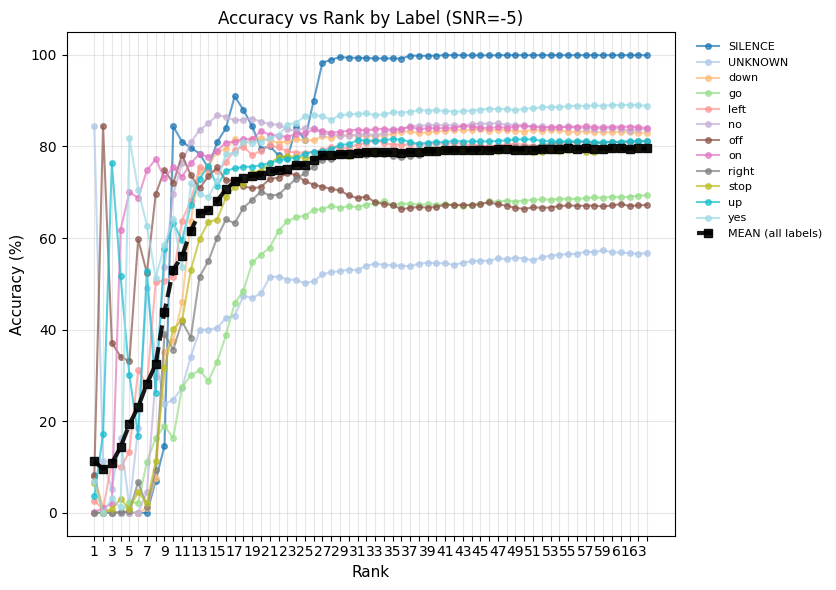

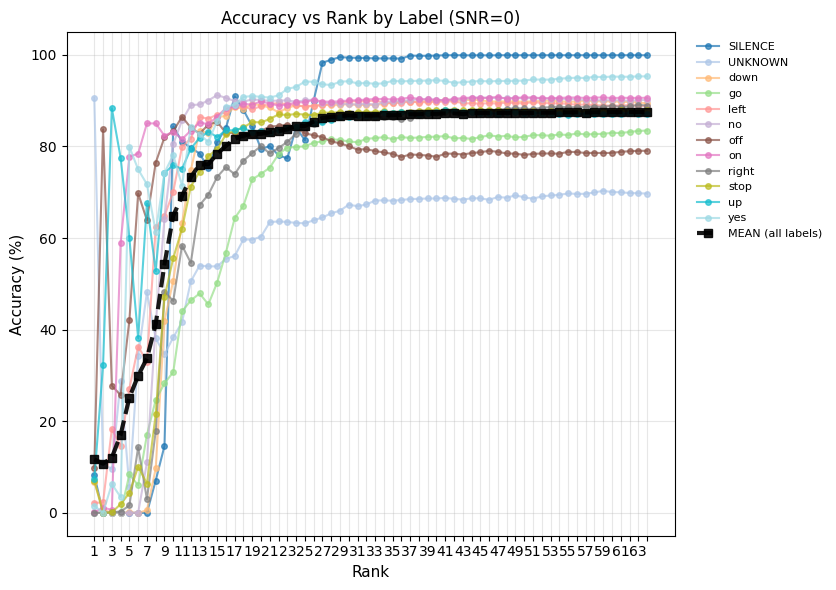

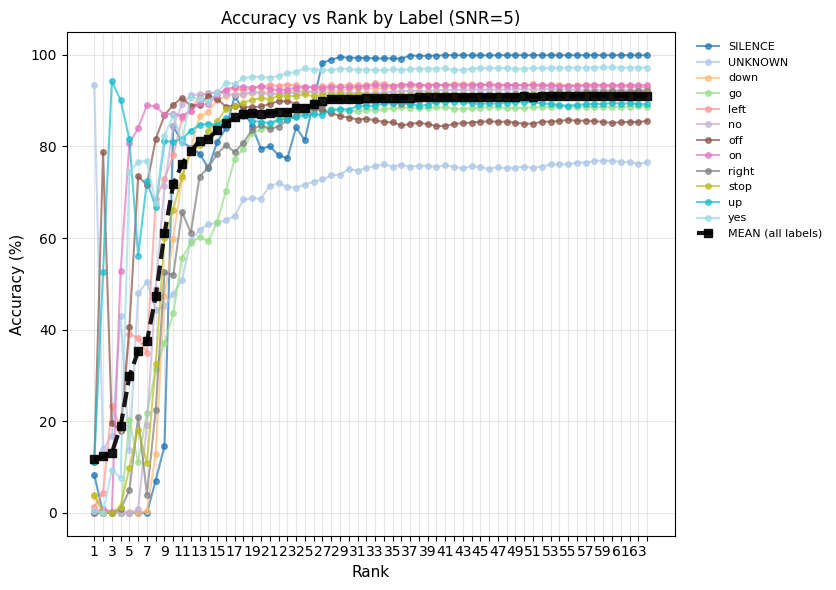

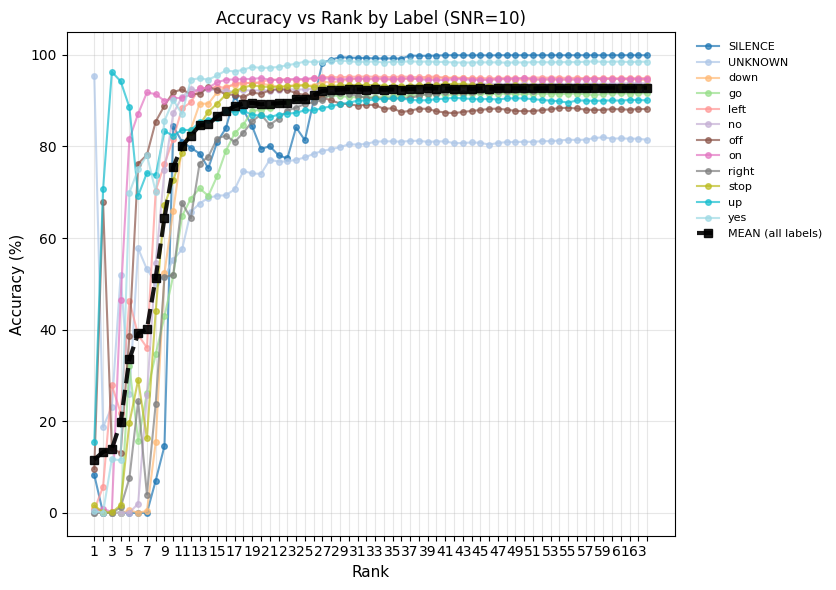

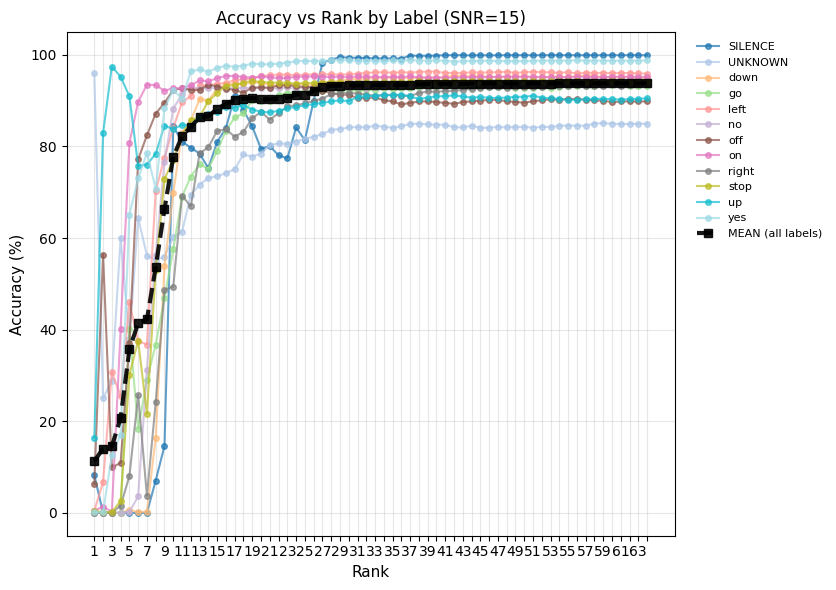

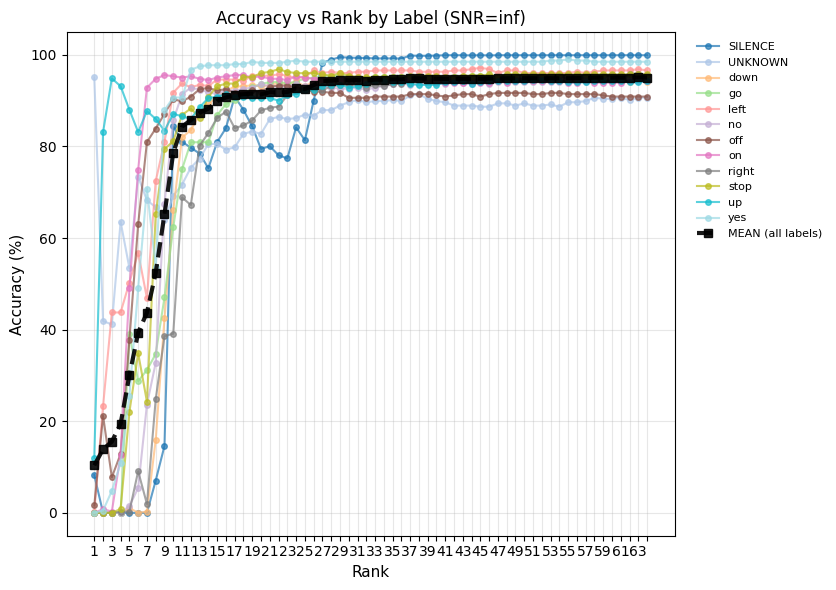

In [19]:
# Example: Plot accuracy vs rank for each label across multiple SNR values
snr_values = [-5, 0, 5, 10, 15, float('inf')]  # Adjust to your desired SNR values

acc_by_label = plot_rank_vs_acc_per_label(
    df=df_for_viz,
    snr_values=snr_values,
    show_mean=True,
    # highlight_labels=["SILENCE", "yes", "no"],  # Uncomment to highlight specific labels
)

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_rank_vs_acc_per_snr(
    df: pd.DataFrame,
    *,
    include_silence: bool = True,
    y_mode: str = "acc",                 # "acc" or "ratio"
    ratio_target: float = 0.8,           # only used when y_mode="ratio"
    plot_per_snr: bool = True,           # NEW: toggle individual SNR plots
    silence_label: str = "SILENCE",
    label_col: str = "label",
    snr_col: str = "snr_eval",
    rank_col: str = "rank",
    correct_col: str = "correct",
    figsize_all=(7, 5),
    figsize_single=(6, 4),
    marker="o",
    print_ratio_summary: bool = True,
):
    """
    Plots:
      1) One plot with ALL SNR curves together (always)
      2) Optionally (plot_per_snr=True) one plot per SNR

    y_mode:
      - "acc"   : accuracy in %
      - "ratio" : accuracy / max_accuracy_per_SNR

    When y_mode="ratio", optionally prints and returns a summary table with
    the minimum rank needed to reach `ratio_target` for each SNR.

    Returns
    -------
    summary : pd.DataFrame
        MultiIndex (rank, snr_eval) with columns:
        [acc_all, acc_non_silence, acc_diff, acc_ratio]
    ratio_rank_summary : pd.DataFrame or None
        Per-SNR summary of min rank to reach ratio_target (only when y_mode="ratio")
    """

    if y_mode not in {"acc", "ratio"}:
        raise ValueError("y_mode must be 'acc' or 'ratio'")

    if y_mode == "ratio" and not (0 < ratio_target <= 1.0):
        raise ValueError("ratio_target must be in (0, 1] when y_mode='ratio'")

    # --- Checks ---
    needed = {snr_col, rank_col, correct_col, label_col}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    # --- Accuracy including silence ---
    g_all = (
        df.assign(is_silence=df[label_col] == silence_label)
          .groupby([rank_col, snr_col], dropna=False)
    )
    acc_all = g_all[correct_col].mean() * 100

    # --- Accuracy excluding silence ---
    df_ns = df[df[label_col] != silence_label]
    acc_non_silence = (
        df_ns.groupby([rank_col, snr_col], dropna=False)[correct_col]
             .mean()
             .mul(100)
    )

    # --- Summary (MultiIndex: rank, snr) ---
    summary = (
        pd.concat(
            {"acc_all": acc_all, "acc_non_silence": acc_non_silence},
            axis=1,
        )
        .assign(acc_diff=lambda d: d["acc_all"] - d["acc_non_silence"])
        .sort_index()
    )

    acc_col = "acc_all" if include_silence else "acc_non_silence"

    # --- Add normalized ratio per SNR ---
    max_acc_per_snr = summary.groupby(level=snr_col)[acc_col].transform("max")
    summary["acc_ratio"] = summary[acc_col] / max_acc_per_snr

    # --- Build ratio->rank summary if needed ---
    ratio_rank_summary = None
    if y_mode == "ratio":
        tmp = summary.reset_index().sort_values([snr_col, rank_col])

        rows = []
        for snr, sub in tmp.groupby(snr_col, sort=False):
            hit = sub[sub["acc_ratio"] >= ratio_target]
            if len(hit) > 0:
                min_rank = int(hit[rank_col].iloc[0])
                achieved_ratio = float(hit["acc_ratio"].iloc[0])
                achieved_acc = float(hit[acc_col].iloc[0])
            else:
                min_rank = None
                achieved_ratio = float(sub["acc_ratio"].max()) if len(sub) else float("nan")
                achieved_acc = float(sub[acc_col].max()) if len(sub) else float("nan")

            rows.append(
                {
                    snr_col: snr,
                    "min_rank_for_ratio": min_rank,
                    "ratio_target": ratio_target,
                    "achieved_ratio_at_min_rank": achieved_ratio if min_rank is not None else None,
                    "acc_at_min_rank": achieved_acc if min_rank is not None else None,
                    "max_acc": float(sub[acc_col].max()) if len(sub) else float("nan"),
                }
            )

        ratio_rank_summary = pd.DataFrame(rows).sort_values(snr_col)

        if print_ratio_summary:
            print(
                f"\n=== Minimum rank to reach acc/max(acc) ≥ {ratio_target:.2f} "
                f"({'acc_all' if include_silence else 'acc_non_silence'}) ==="
            )
            print(ratio_rank_summary.to_string(index=False))

    # =========================
    # 1) ALL SNRs IN ONE PLOT
    # =========================
    plt.figure(figsize=figsize_all)

    for snr in summary.index.get_level_values(snr_col).unique():
        sub = summary.xs(snr, level=snr_col).reset_index()
        y = sub["acc_ratio"] if y_mode == "ratio" else sub[acc_col]

        plt.plot(
            sub[rank_col],
            y,
            marker=marker,
            label=f"SNR={snr}",
        )

    plt.xlabel("Rank")
    ylabel = "Accuracy / max(Accuracy)" if y_mode == "ratio" else "Accuracy (%)"
    plt.ylabel(ylabel)
    plt.title(f"Rank vs {ylabel} — all SNRs")
    plt.grid(True)

    if y_mode == "ratio":
        plt.axhline(ratio_target, linestyle="--")
    plt.legend(title="SNR")
    plt.tight_layout()
    plt.show()

    # =========================
    # 2) OPTIONAL: ONE PLOT PER SNR
    # =========================
    if plot_per_snr:
        for snr in summary.index.get_level_values(snr_col).unique():
            sub = summary.xs(snr, level=snr_col).reset_index()
            y = sub["acc_ratio"] if y_mode == "ratio" else sub[acc_col]

            plt.figure(figsize=figsize_single)
            plt.plot(sub[rank_col], y, marker=marker)
            plt.xlabel("Rank")
            plt.ylabel(ylabel)
            plt.title(f"Rank vs {ylabel} (SNR={snr})")
            plt.grid(True)

            if y_mode == "ratio":
                plt.axhline(ratio_target, linestyle="--")

                # vertical line at min rank (if exists)
                if ratio_rank_summary is not None:
                    r = ratio_rank_summary.loc[
                        ratio_rank_summary[snr_col] == snr, "min_rank_for_ratio"
                    ]
                    if len(r) and pd.notna(r.iloc[0]):
                        plt.axvline(int(r.iloc[0]), linestyle="--")

            plt.tight_layout()
            plt.show()

    return summary, ratio_rank_summary

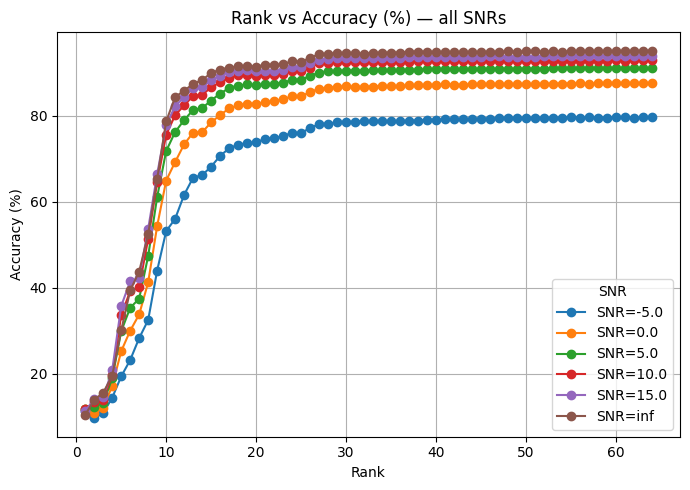


=== Minimum rank to reach acc/max(acc) ≥ 0.95 (acc_all) ===
 snr_eval  min_rank_for_ratio  ratio_target  achieved_ratio_at_min_rank  acc_at_min_rank   max_acc
     -5.0                  24          0.95                    0.955509        76.028055 79.568106
      0.0                  22          0.95                    0.952011        83.337025 87.537837
      5.0                  18          0.95                    0.955048        86.976744 91.070506
     10.0                  17          0.95                    0.956306        88.789221 92.846069
     15.0                  16          0.95                    0.951836        89.291251 93.809524
      inf                  16          0.95                    0.953952        90.697674 95.075674


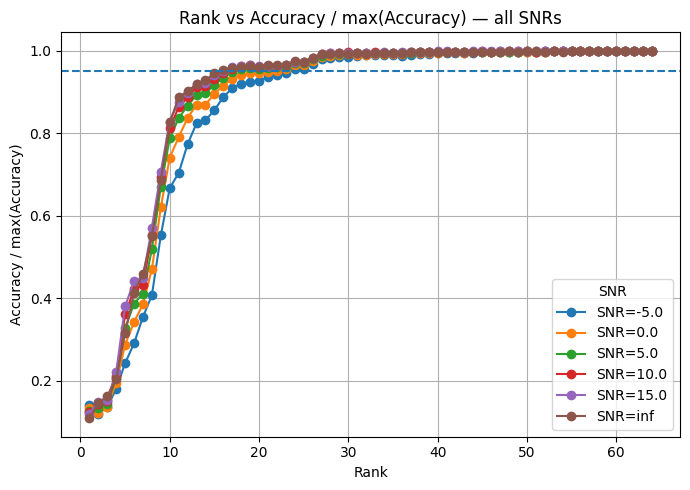

In [17]:
# Normal accuracy plots
summary, ratio_tbl = plot_rank_vs_acc_per_snr(df, include_silence=True, y_mode="acc",plot_per_snr=False)

# Ratio plots + printed table of min rank per SNR to reach 0.8
summary, ratio_tbl = plot_rank_vs_acc_per_snr(
    df,
    include_silence=True,
    y_mode="ratio",
    ratio_target=0.95,
    print_ratio_summary=True,
    plot_per_snr=False,
)